In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from statsmodels.tsa.seasonal import seasonal_decompose

import helper

## GasolineSales1

In [2]:
# Read the Excel file
df = pd.read_excel("GasolineSales1.xlsx")
weeks = df.iloc[:, 0]
y_gs1 = df.iloc[:, 1]

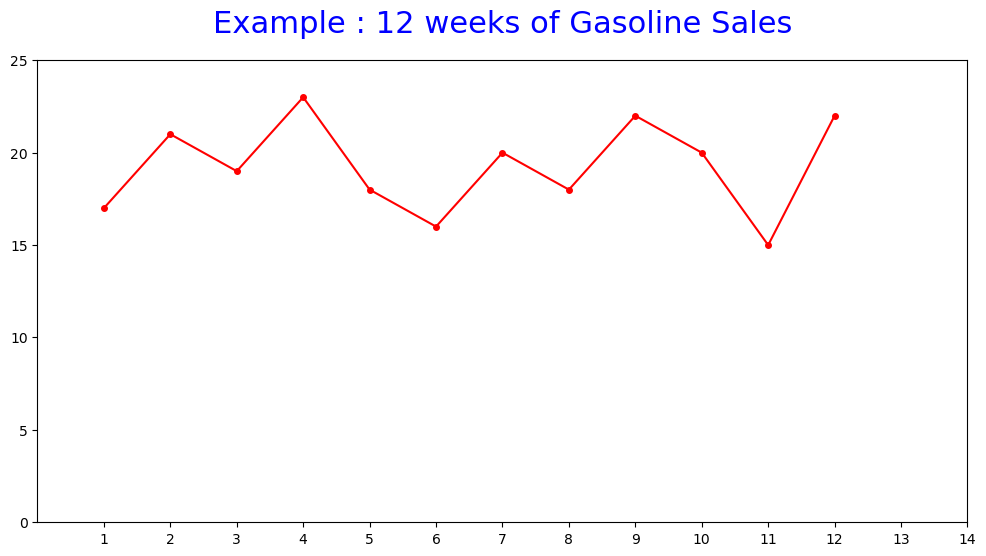

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    weeks,
    y_gs1,
    color='red',
    marker='o',
    linewidth=1.5,
    markersize=4
)


plt.xlim(0, 14)
plt.ylim(0, 25)
plt.xticks(range(1, 15))
plt.yticks(range(0, 26, 5))

# Labels
plt.xlabel("")
plt.ylabel("")

# Title styling
plt.title(
    "Example : 12 weeks of Gasoline Sales",
    fontsize=22,
    color='blue',
    pad=20
)

plt.grid(False)
plt.show()

### Average
Let $Y_t$ denote weekly gasoline sales observed for $t=1,\dots,12$.
$$
\bar Y = \frac{1}{T}\sum_{t=1}^{T} Y_t, \qquad T=12.
$$
For the observed data,
$$
\bar Y = \frac{17+21+19+23+18+16+20+18+22+20+15+22}{12} = 19.25.
$$

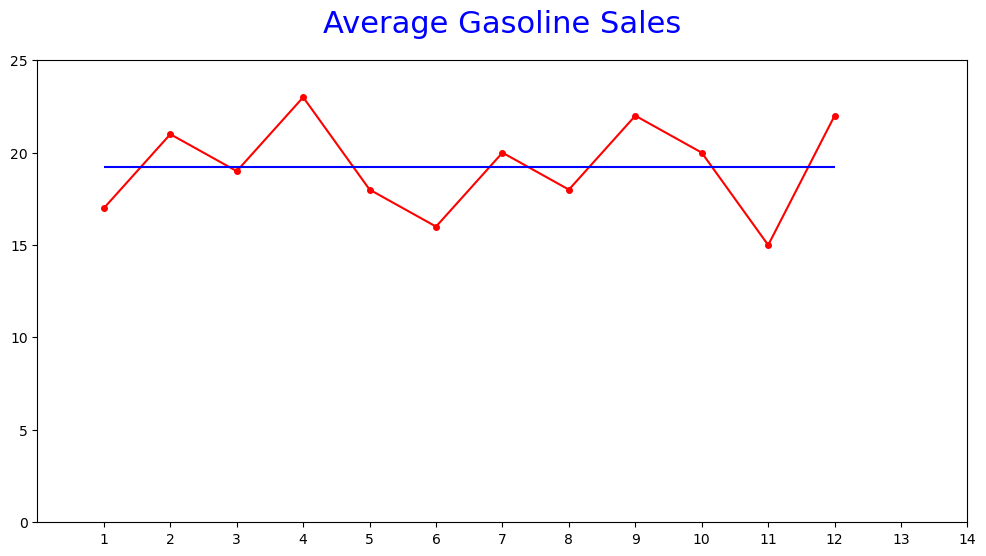

In [4]:
# Compute average
average_sales = y_gs1.mean()

plt.figure(figsize=(12, 6))

# Plot gasoline sales
plt.plot(
    weeks,
    y_gs1,
    color='red',
    marker='o',
    linewidth=1.5,
    markersize=4
)

# Plot average line
plt.hlines(
    average_sales,
    xmin=1,
    xmax=12,
    colors='blue',
    linewidth=1.5
)

# Axis limits and ticks
plt.xlim(0, 14)
plt.ylim(0, 25)
plt.xticks(range(1, 15))
plt.yticks(range(0, 26, 5))

# Remove axis labels (as in image)
plt.xlabel("")
plt.ylabel("")

# Title styling
plt.title(
    "Average Gasoline Sales",
    fontsize=22,
    color='blue',
    pad=20
)

# No grid, classic look
plt.grid(False)

plt.show()

### Running Average

The average can be computed for the first $J$ observations, for $J=1,\dots,T$.
$$
\bar Y_J = \frac{1}{J}\sum_{j=1}^{J} Y_j, \qquad J=1,\dots,T.
$$
In this way, we obtain $T=12$ different averages: $\bar Y_1,\dots,\bar Y_T$.

In [5]:
def running_average(values):
    running_avg = []
    cumulative_sum = 0.0

    for i, v in enumerate(values, start=1):
        cumulative_sum += v
        running_avg.append(cumulative_sum / i)

    return running_avg

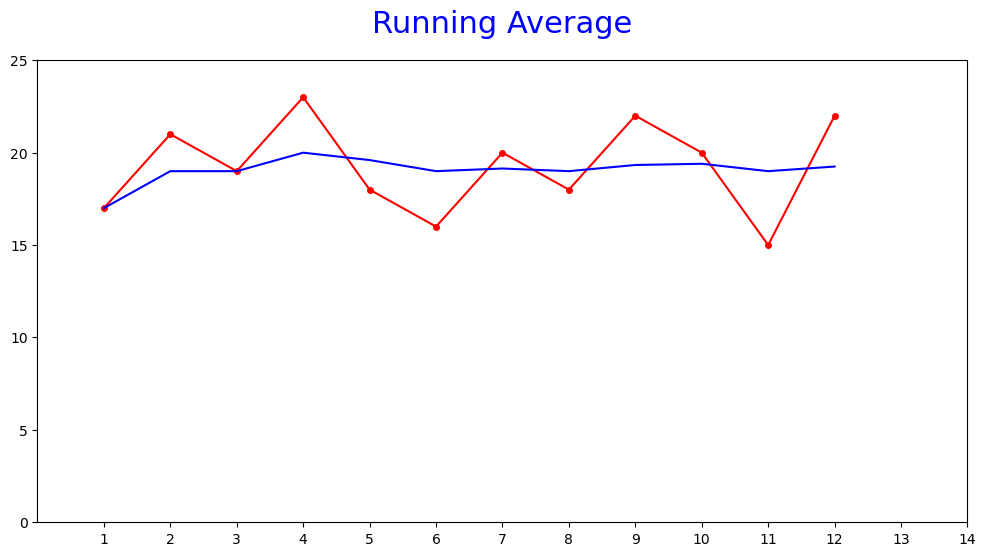

In [6]:
# Compute running average
# running_average = gasoline_sales.expanding().mean()
running_avg_sales = running_average(y_gs1)

# Plot running average figure
plt.figure(figsize=(12, 6))

# Gasoline sales (red)
plt.plot(
    weeks,
    y_gs1,
    color='red',
    marker='o',
    linewidth=1.5,
    markersize=4
)

# Running average (blue)
plt.plot(
    weeks,
    running_avg_sales,
    color='blue',
    linewidth=1.5
)

# Axis limits and ticks
plt.xlim(0, 14)
plt.ylim(0, 25)
plt.xticks(range(1, 15))


# Remove labels
plt.xlabel("")
plt.ylabel("")

# Title
plt.title(
    "Running Average",
    fontsize=22,
    color='blue',
    pad=20
)

plt.grid(False)
plt.show()

### Forecasting: Assessment

We observe $Y_1,\dots,Y_T$ and evaluate forecasts using only past information.

**Real-time (one-step-ahead) forecast**
$$
\hat Y_t^{F} = \bar Y_{t-1}, \qquad t = 2,\dots,T,
$$
where $\bar Y_{t-1}$ is the running average based on observations up to $t-1$.
(No forecast is available for $Y_1$.)

**Forecast error**
$$
U_t = Y_t - \hat Y_t^{F}, \qquad t = 2,\dots,T.
$$

Forecast accuracy is assessed using the sequence $\{U_t\}_{t=2}^T$.

In [7]:
def forecast_errors(y, yhat):
    """
    Compute one-step-ahead forecast errors:
    U_t = Y_t - Ŷ_t, with None at t=1
    """
    n = len(y)
    u = [None] * n

    for t in range(1, n):
        u[t] = float(y[t]) - float(yhat[t])

    return u

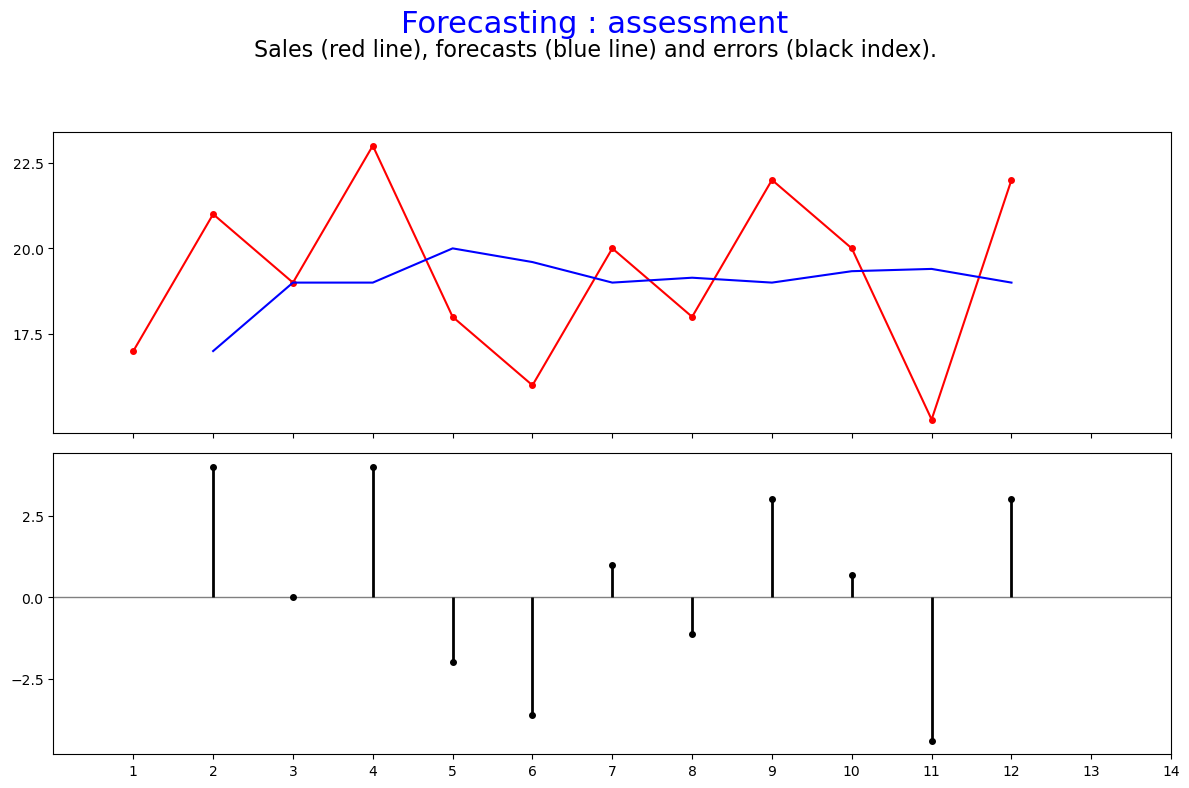

In [8]:
# Construct real-time one-step-ahead forecasts \hat{Y}_t^F = \bar{Y}_{t-1} for t=2,\dots,T
yhat_ra = [None] * len(running_avg_sales)
yhat_ra[0] = None
for i in range(1, len(running_avg_sales)):
    yhat_ra[i] = running_avg_sales[i - 1]

# Compute forecast errors U_t = Y_t - \hat{Y}_t^F for t=2,\dots,T
u_gs1 = forecast_errors(y_gs1, yhat_ra)

# Create a two-panel plot: sales and forecasts (top), forecast errors (bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot observed sales (red) and real-time forecasts (blue)
ax1.plot(weeks, y_gs1, color='red', marker='o', linewidth=1.5, markersize=4)
ax1.plot(weeks, yhat_ra, color='blue', linewidth=1.5)
ax1.set_xlim(0, 14)
ax1.set_xticks(range(1, 15))
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_yticks([17.5, 20.0, 22.5])
ax1.grid(False)

# Plot forecast errors as vertical indices (black) with a zero reference line
ax2.axhline(0, color='gray', linewidth=1)
ax2.vlines(weeks[1:], 0, u_gs1[1:], color='black', linewidth=2)
ax2.plot(weeks[1:], u_gs1[1:], 'ko', markersize=4)
ax2.set_xlim(0, 14)
ax2.set_xticks(range(1, 15))
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_yticks([-2.5, 0, 2.5])
ax2.grid(False)

# Add title and subtitle
fig.suptitle("Forecasting : assessment", fontsize=22, color='blue', y=0.98)
fig.text(
    0.5, 0.93,
    "Sales (red line), forecasts (blue line) and errors (black index).",
    ha="center", va="center", fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [9]:
title = "FORECASTING REPORT FOR SALES"
line_eq = "=" * 46
line_dash = "-" * 46

print(title)
print(line_eq)
print(f"{'':>3}{'Y_t':>6}{'Y^F_t':>10}{'U_t':>8}{'...':>6}")
print(line_dash)

for i in range(1, len(weeks)):
    t_i = int(weeks.iloc[i])
    y_i = float(y_gs1.iloc[i])
    yhat_i = float(yhat_ra[i])
    u_i = float(u_gs1[i])
    print(f"{t_i:>3}{y_i:>6.0f}{yhat_i:>10.2f}{u_i:>8.2f}")
print()
print(f"{'Avg':>3}{y_gs1.iloc[1:].mean():>6.2f}{'':>10}{pd.Series(u_gs1[1:]).mean():>8.2f}")
print(line_eq)

FORECASTING REPORT FOR SALES
      Y_t     Y^F_t     U_t   ...
----------------------------------------------
  2    21     17.00    4.00
  3    19     19.00    0.00
  4    23     19.00    4.00
  5    18     20.00   -2.00
  6    16     19.60   -3.60
  7    20     19.00    1.00
  8    18     19.14   -1.14
  9    22     19.00    3.00
 10    20     19.33    0.67
 11    15     19.40   -4.40
 12    22     19.00    3.00

Avg 19.45              0.41


### Forecasting Precision Measures (using $U_t = Y_t - \hat Y_t^{F}$)

Let forecasts be available for $t=\tau,\dots,T$ ($\tau=2$ for one-step-ahead real-time forecasts).
Define the forecast error
$$
U_t = Y_t - \hat Y_t^{F}, \qquad t=\tau,\dots,T.
$$

Then the standard precision measures are
$$
\mathrm{ME} = \frac{1}{T+1-\tau}\sum_{t=\tau}^{T} U_t,
\qquad
\mathrm{MAE} = \frac{1}{T+1-\tau}\sum_{t=\tau}^{T} |U_t|,
$$
$$
\mathrm{MAPE} = \frac{100}{T+1-\tau}\sum_{t=\tau}^{T}\frac{|U_t|}{|Y_t|},
\qquad
\mathrm{MSE} = \frac{1}{T+1-\tau}\sum_{t=\tau}^{T} U_t^{2}.
$$

For the forecasting report table, additionally compute
$$
|U_t|,\qquad 100\cdot\frac{|U_t|}{|Y_t|},\qquad U_t^2,
\qquad t=\tau,\dots,T.
$$


In [10]:
def forecast_metrics(u, y, tau=1):
    """
    Forecast precision measures for t = tau,...,T
    Inputs
    ------
    u : array-like
        Forecast errors U_t = Y_t - Ŷ_t
    y : array-like
        Actual values Y_t (needed for MAPE)
    tau : int
        Lower summation bound
    """
    u = np.asarray(u, dtype=float)[tau-1:]
    y = np.asarray(y, dtype=float)[tau-1:]

    me = u.mean()
    mae = np.abs(u).mean()
    mape = (100.0 * np.abs(u) / np.abs(y)).mean()
    mse = (u ** 2).mean()

    return {
        "ME": me,
        "MAE": mae,
        "MAPE": mape,
        "MSE": mse,
    }

In [11]:
tau = 2
t_vals = weeks.iloc[tau-1:].astype(int).to_numpy()
Y = y_gs1.iloc[tau-1:].astype(float).to_numpy()
Yhat = np.array([float(v) for v in yhat_ra[tau-1:]])
U = np.array([float(v) for v in u_gs1[tau-1:]])

absU = np.abs(U)
pct_absU = 100.0 * absU / np.abs(Y)
U2 = U**2

metrics = forecast_metrics(u_gs1, y_gs1, tau=2)
ME = metrics["ME"]
MAE = metrics["MAE"]
MAPE = metrics["MAPE"]
MSE = metrics["MSE"]

title = "FORECASTING REPORT FOR SALES"
line_eq = "=" * 60
line_dash = "-" * 60

print(title)
print(line_eq)
print(
    f"{'':>3}"
    f"{'Y_t':>6}"
    f"{'Y^F_t':>10}"
    f"{'U_t':>8}"
    f"{'|U_t|':>8}"
    f"{'%|U_t|':>10}"
    f"{'U_t^2':>10}"
)
print(line_dash)

for i in range(len(t_vals)):
    print(
        f"{t_vals[i]:>3}"
        f"{Y[i]:>6.0f}"
        f"{Yhat[i]:>10.2f}"
        f"{U[i]:>8.2f}"
        f"{absU[i]:>8.2f}"
        f"{pct_absU[i]:>10.2f}"
        f"{U2[i]:>10.2f}"
    )
    
# Metrics row header
print()
print(
    f"{'':>3}"
    f"{'':>6}"
    f"{'':>10}"
    f"{'ME':>8}"
    f"{'MAE':>8}"
    f"{'MAPE':>10}"
    f"{'MSE':>10}"
)

# Metrics values
print(
    f"{'Avg':>3}"
    f"{'':>6}"
    f"{'':>10}"
    f"{ME:>8.2f}"
    f"{MAE:>8.2f}"
    f"{MAPE:>10.2f}"
    f"{MSE:>10.2f}"
)

print(line_eq)

FORECASTING REPORT FOR SALES
      Y_t     Y^F_t     U_t   |U_t|    %|U_t|     U_t^2
------------------------------------------------------------
  2    21     17.00    4.00    4.00     19.05     16.00
  3    19     19.00    0.00    0.00      0.00      0.00
  4    23     19.00    4.00    4.00     17.39     16.00
  5    18     20.00   -2.00    2.00     11.11      4.00
  6    16     19.60   -3.60    3.60     22.50     12.96
  7    20     19.00    1.00    1.00      5.00      1.00
  8    18     19.14   -1.14    1.14      6.35      1.31
  9    22     19.00    3.00    3.00     13.64      9.00
 10    20     19.33    0.67    0.67      3.33      0.44
 11    15     19.40   -4.40    4.40     29.33     19.36
 12    22     19.00    3.00    3.00     13.64      9.00

                         ME     MAE      MAPE       MSE
Avg                    0.41    2.44     12.85      8.10


### Forecast Comparisons

For each method, define the one-step-ahead forecast error (for $t=2,\dots,T$):
$$
U_t = Y_t - \hat{Y}_t^{F}.
$$

Compute the precision measures:
$$
\mathrm{ME}=\frac{1}{T+1-\tau}\sum_{t=\tau}^{T}U_t,\qquad
\mathrm{MAE}=\frac{1}{T+1-\tau}\sum_{t=\tau}^{T}|U_t|,
$$
$$
\mathrm{MAPE}=\frac{100}{T+1-\tau}\sum_{t=\tau}^{T}\frac{|U_t|}{|Y_t|},\qquad
\mathrm{MSE}=\frac{1}{T+1-\tau}\sum_{t=\tau}^{T}U_t^2.
$$

Benchmarks:
- **Running Avg:** $\hat{Y}_t^{F}=\bar{Y}_{t-1}$  
- **Random Walk:** $\hat{Y}_t^{RW}=Y_{t-1}$  
- **Expert:** $\hat{Y}_t^{E}=E$ (constant)

In [12]:
def lag_forecast(series):
    """Ŷ_t = series_{t-1}, with None at t=1"""
    n = len(series)
    yhat = [None] * n
    for t in range(1, n):
        yhat[t] = float(series[t - 1])
    return yhat

In [13]:
# --- Running Average method 
u_run = forecast_errors(y_gs1, yhat_ra)
metrics_run = forecast_metrics(u_run, y_gs1, tau=2)
ME_run, MAE_run, MAPE_run, MSE_run = (
    metrics_run["ME"], metrics_run["MAE"], metrics_run["MAPE"], metrics_run["MSE"]
)

# --- Random Walk benchmark: \hat{Y}_t = Y_{t-1} ---
yhat_rw = lag_forecast(y_gs1)
u_rw = forecast_errors(y_gs1, yhat_rw)
metrics_rw = forecast_metrics(u_rw, y_gs1, tau=2)
ME_rw, MAE_rw, MAPE_rw, MSE_rw = (
    metrics_rw["ME"], metrics_rw["MAE"], metrics_rw["MAPE"], metrics_rw["MSE"]
)

# --- Expert benchmark: \hat{Y}_t = E (constant) ---
E = 19.0
yhat_exp = [None] + [E] * (len(y_gs1) - 1)   # None at t=1 to match one-step-ahead convention
u_exp = forecast_errors(y_gs1, yhat_exp)
metrics_exp = forecast_metrics(u_exp, y_gs1, tau=2)

ME_exp, MAE_exp, MAPE_exp, MSE_exp = (
    metrics_exp["ME"], metrics_exp["MAE"], metrics_exp["MAPE"], metrics_exp["MSE"]
)

# --- ASCII table output (line_eq / line_dash style) ---
title = "FORECAST COMPARISONS, ALL 11 FORECASTS"
line_eq = "=" * 56
line_dash = "-" * 56

print(title)
print(line_eq)
print(f"{'Method':<18}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>7}")
print(line_dash)

print(f"{'Running Avg':<18}{ME_run:>7.2f}{MAE_run:>7.2f}{MAPE_run:>8.2f}{MSE_run:>7.2f}")
print(f"{'Random Walk':<18}{ME_rw:>7.2f}{MAE_rw:>7.2f}{MAPE_rw:>8.2f}{MSE_rw:>7.2f}")
print(f"{f'Expert (E = {int(E)})':<18}{ME_exp:>7.2f}{MAE_exp:>7.2f}{MAPE_exp:>8.2f}{MSE_exp:>7.2f}")

print(line_eq)
print("ME = Mean Error")
print("MAE = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE = Mean Squared Error")

FORECAST COMPARISONS, ALL 11 FORECASTS
Method                 ME    MAE    MAPE    MSE
--------------------------------------------------------
Running Avg          0.41   2.44   12.85   8.10
Random Walk          0.45   3.73   19.24  16.27
Expert (E = 19)      0.45   2.09   10.97   6.09
ME = Mean Error
MAE = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE = Mean Squared Error


### Forecast Comparisons (Last 6 Forecasts)

Let the evaluation window be restricted to the **last 6 one-step-ahead forecasts**,
that is
$$
t = T-5, \dots, T.
$$

For each method, define the forecast error
$$
U_t = Y_t - \hat{Y}_t^{F},
$$
and compute the precision measures over this restricted window:
$$
\mathrm{ME}=\frac{1}{6}\sum U_t,\quad
\mathrm{MAE}=\frac{1}{6}\sum |U_t|,
$$
$$
\mathrm{MAPE}=\frac{100}{6}\sum \frac{|U_t|}{|Y_t|},\quad
\mathrm{MSE}=\frac{1}{6}\sum U_t^2.
$$

Methods compared:
- **Running Average:** $\hat{Y}_t^F=\bar Y_{t-1}$
- **Random Walk:** $\hat{Y}_t^{RW}=Y_{t-1}$
- **Expert:** $\hat{Y}_t^{E}=E$


In [14]:
# ===== Last-6-forecasts evaluation + ASCII table =====

H = 6  # last 6 forecasts only

# --- Running Average method ---
u_run = forecast_errors(y_gs1, yhat_ra)
u_run_6 = u_run[-H:]
y_run_6 = y_gs1[-H:]
metrics_run_6 = forecast_metrics(u_run_6, y_run_6, tau=1)

# --- Random Walk benchmark ---
yhat_rw = lag_forecast(y_gs1)
u_rw = forecast_errors(y_gs1, yhat_rw)
u_rw_6 = u_rw[-H:]
y_rw_6 = y_gs1[-H:]
metrics_rw_6 = forecast_metrics(u_rw_6, y_rw_6, tau=1)

# --- Expert benchmark ---
E = 19.0
yhat_exp = [None] + [E] * (len(y_gs1) - 1)
u_exp = forecast_errors(y_gs1, yhat_exp)
u_exp_6 = u_exp[-H:]
y_exp_6 = y_gs1[-H:]
metrics_exp_6 = forecast_metrics(u_exp_6, y_exp_6, tau=1)

# --- Extract metrics ---
ME_run_6, MAE_run_6, MAPE_run_6, MSE_run_6 = (
    metrics_run_6["ME"], metrics_run_6["MAE"], metrics_run_6["MAPE"], metrics_run_6["MSE"]
)
ME_rw_6, MAE_rw_6, MAPE_rw_6, MSE_rw_6 = (
    metrics_rw_6["ME"], metrics_rw_6["MAE"], metrics_rw_6["MAPE"], metrics_rw_6["MSE"]
)
ME_exp_6, MAE_exp_6, MAPE_exp_6, MSE_exp_6 = (
    metrics_exp_6["ME"], metrics_exp_6["MAE"], metrics_exp_6["MAPE"], metrics_exp_6["MSE"]
)

# --- ASCII table output ---
title = f"FORECAST COMPARISONS, LAST {H} FORECASTS"
line_eq = "=" * 56
line_dash = "-" * 56

print(title)
print(line_eq)
print(f"{'Method':<18}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>7}")
print(line_dash)

print(f"{'Running Avg':<18}{ME_run_6:>7.2f}{MAE_run_6:>7.2f}{MAPE_run_6:>8.2f}{MSE_run_6:>7.2f}")
print(f"{'Random Walk':<18}{ME_rw_6:>7.2f}{MAE_rw_6:>7.2f}{MAPE_rw_6:>8.2f}{MSE_rw_6:>7.2f}")
print(f"{f'Expert (E = {int(E)})':<18}{ME_exp_6:>7.2f}{MAE_exp_6:>7.2f}{MAPE_exp_6:>8.2f}{MSE_exp_6:>7.2f}")

print(line_eq)
print("ME = Mean Error")
print("MAE = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE = Mean Squared Error")


FORECAST COMPARISONS, LAST 6 FORECASTS
Method                 ME    MAE    MAPE    MSE
--------------------------------------------------------
Running Avg          0.35   2.20   11.88   6.69
Random Walk          1.00   4.00   20.74  19.00
Expert (E = 19)      0.50   2.17   11.58   6.17
ME = Mean Error
MAE = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE = Mean Squared Error


### Exponential Smoothing and Forecast Weights

**Exponential smoothing recursion**
$$
\hat Y_{t+1}^{F}=\alpha Y_t + (1-\alpha)\hat Y_t^{F},\qquad t=1,\dots,T,
\qquad \hat Y_1^{F}=Y_1,\; 0<\alpha\le 1.
$$

**Weighted-average form**
$$
\hat Y_{T+1}^{F}
= \sum_{j=0}^{T-2}\alpha(1-\alpha)^j\,Y_{T-j} \;+\; (1-\alpha)^{T-1}Y_1.
$$

**Generic forecast function**
$$
\hat Y_{T+1}^{F}=\omega_0Y_T+\omega_1Y_{T-1}+\cdots+\omega_{T-1}Y_1.
$$

**Examples of weights (for 50 past observations)**
- Running average: $\omega_j=\frac{1}{50}$ for all $j$.
- Moving average (window $M$): $\omega_j=\frac{1}{M}$ for $j=0,\dots,M-1$, and $0$ otherwise.
- Random walk: $\omega_0=1$, $\omega_j=0$ for $j\ge 1$.
- Exponential smoothing: $\omega_j=\alpha(1-\alpha)^j$ for $j=0,\dots,48$, and $\omega_{49}=(1-\alpha)^{49}$.


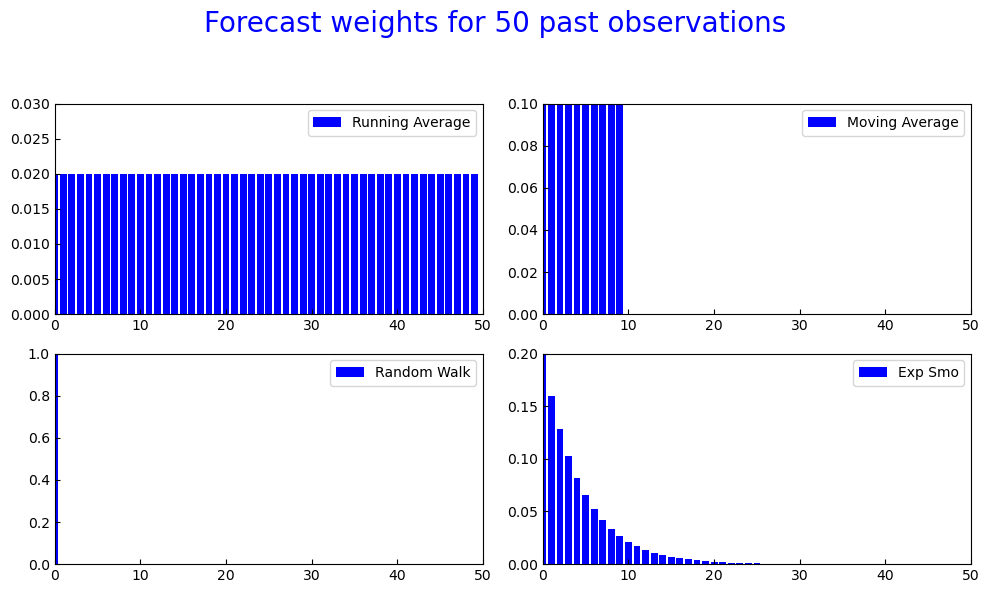

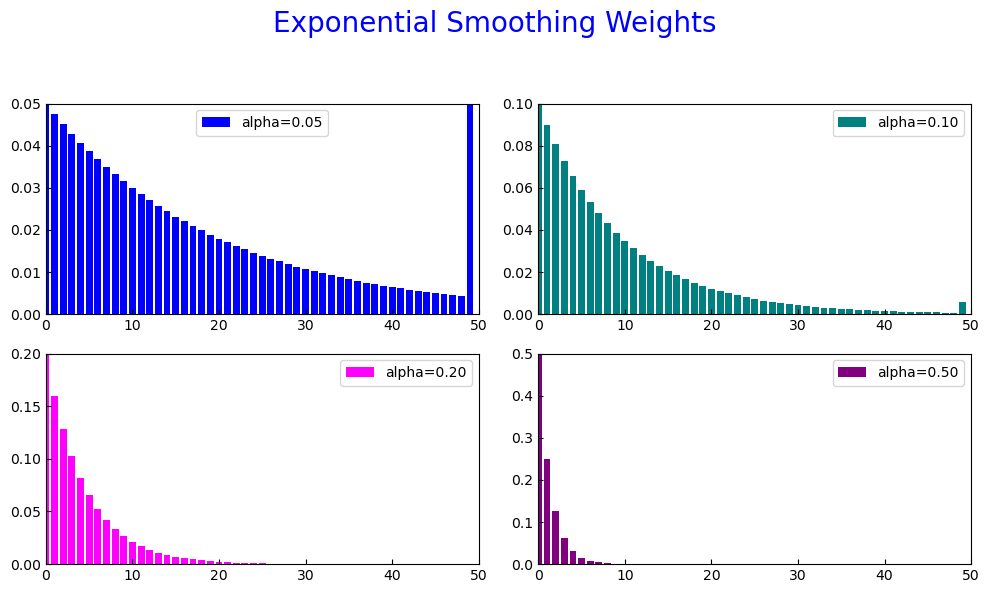

In [15]:
# Number of past observations
T = 50
j = np.arange(T)

# --- Figure 1: Forecast weights for 50 past observations (4 panels) ---
# Running average weights
w_run = np.ones(T) / T

# Moving average weights (window M = 10)
M = 10
w_mov = np.zeros(T)
w_mov[:M] = 1.0 / M

# Random walk weights
w_rw = np.zeros(T)
w_rw[0] = 1.0

# Exponential smoothing weights (alpha = 0.10)
alpha0 = 0.20
w_exp = alpha0 * (1 - alpha0) ** j
w_exp[-1] = (1 - alpha0) ** (T - 1)

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Forecast weights for 50 past observations", fontsize=20, color="blue")

axs[0, 0].bar(j, w_run, color="blue")
axs[0, 0].set_xlim(0, 50)
axs[0, 0].set_ylim(0, 0.03)
axs[0, 0].legend(["Running Average"], frameon=True)

axs[0, 1].bar(j, w_mov, color="blue")
axs[0, 1].set_xlim(0, 50)
axs[0, 1].set_ylim(0, 0.10)
axs[0, 1].legend(["Moving Average"], frameon=True)

axs[1, 0].bar(j, w_rw, color="blue")
axs[1, 0].set_xlim(0, 50)
axs[1, 0].set_ylim(0, 1.00)
axs[1, 0].legend(["Random Walk"], frameon=True)

axs[1, 1].bar(j, w_exp, color="blue")
axs[1, 1].set_xlim(0, 50)
axs[1, 1].set_ylim(0, 0.20)
axs[1, 1].legend(["Exp Smo"], frameon=True)

for ax in axs.ravel():
    ax.tick_params(direction="in")
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- Figure 2: Exponential Smoothing Weights for different alpha ---
alphas = [0.05, 0.10, 0.20, 0.50]
ylims = [0.05, 0.10, 0.20, 0.50]
colors = ["blue", "teal", "magenta", "purple"]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Exponential Smoothing Weights", fontsize=20, color="blue")

for ax, a, ylim, c in zip(axs.ravel(), alphas, ylims, colors):
    w = a * (1 - a) ** j
    w[-1] = (1 - a) ** (T - 1)
    ax.bar(j, w, color=c)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, ylim)
    ax.legend([f"alpha={a:.2f}"], frameon=True)
    ax.tick_params(direction="in")
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Memory Index (Exponential Smoothing)

Exponential-smoothing weights satisfy
$$
\omega_j = \alpha(1-\alpha)^j,\qquad j=0,1,2,\dots
$$

The **scaled** weight (dividing by $\alpha$) is
$$
\frac{\omega_j}{\alpha} = (1-\alpha)^j.
$$

Fix a relevance threshold $c$ (e.g. $c=0.10$).  
The **memory index** $m_\alpha$ is the largest lag $J$ such that the scaled weight is still relevant:
$$
(1-\alpha)^J > c.
$$

Solving for $J$ gives
$$
m_\alpha = \frac{\log(c)}{\log(1-\alpha)}.
$$

For $c=0.10$,
$$
m_\alpha = \frac{\log(0.1)}{\log(1-\alpha)}.
$$


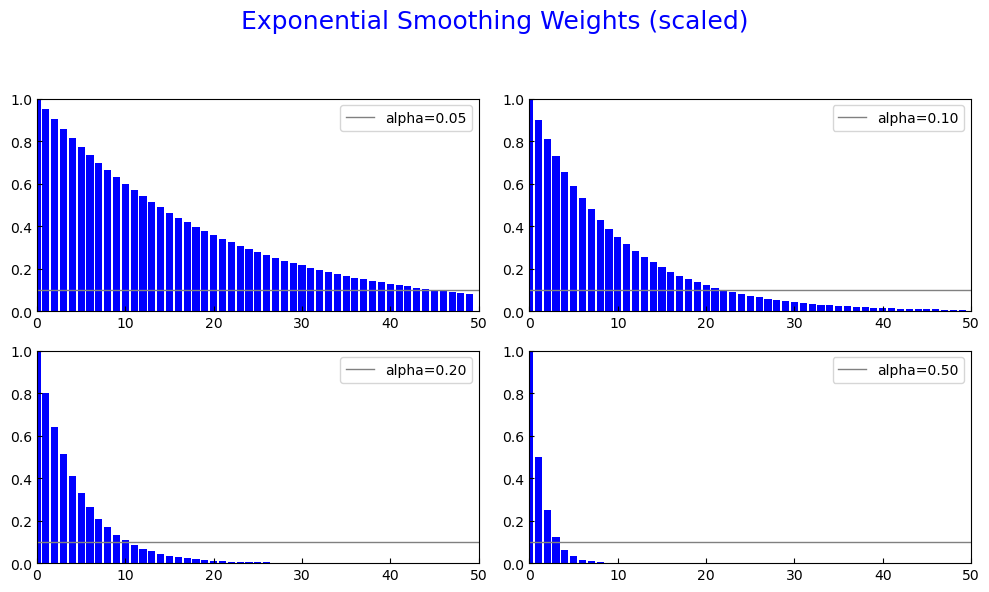

In [16]:
alphas = [0.05, 0.10, 0.20, 0.50]
threshold = 0.10

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Exponential Smoothing Weights (scaled)", fontsize=18, color="blue")

for ax, a in zip(axs.ravel(), alphas):
    # Scaled weights: (1 - alpha)^j
    w_scaled = (1 - a) ** j

    # Bars (blue, as in reference figure)
    ax.bar(j, w_scaled, color="blue")

    # Threshold line
    ax.axhline(threshold, color="gray", linewidth=1)

    # # Memory index: largest j such that (1 - alpha)^j > 0.10
    # m_alpha = int(np.floor(np.log(threshold) / np.log(1 - a)))
    # ax.plot(
    #     m_alpha,
    #     w_scaled[m_alpha],
    #     marker="o",
    #     markersize=8,
    #     markerfacecolor="none",
    #     markeredgecolor="purple",
    #     markeredgewidth=1.5,
    # )

    ax.set_xlim(0, 50)
    ax.set_ylim(0, 1.0)
    ax.legend([f"alpha={a:.2f}"], frameon=True)
    ax.tick_params(direction="in")
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


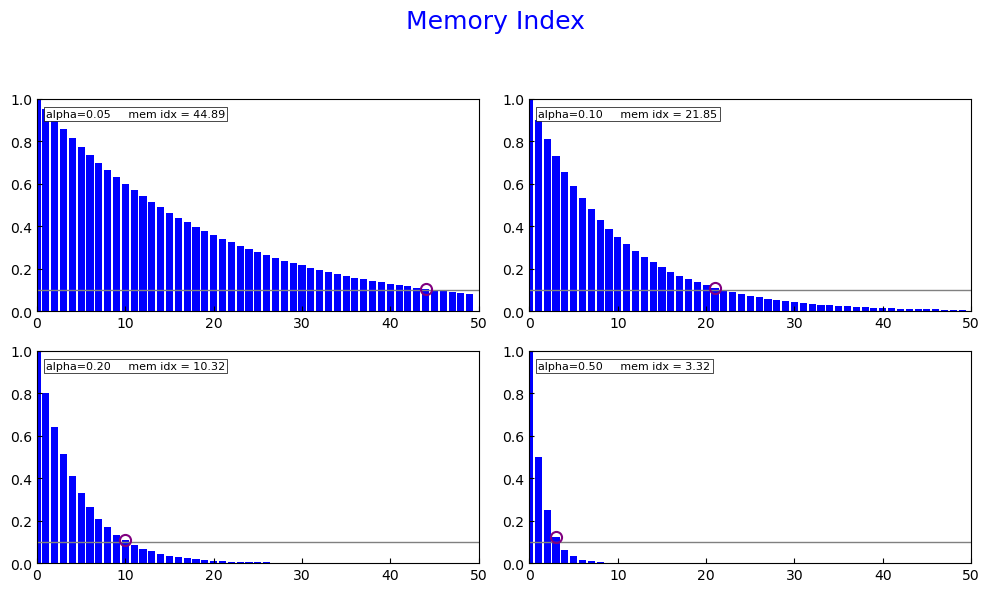

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Memory Index", fontsize=18, color="blue")

for ax, a in zip(axs.ravel(), alphas):
    # Scaled weights: (1 - alpha)^j
    w_scaled = (1 - a) ** j

    # Memory index (real-valued)
    m_alpha = np.log(threshold) / np.log(1 - a)

    # Memory index (integer location for plotting on discrete bars)
    m_idx = int(np.floor(m_alpha))
    m_idx = max(0, min(m_idx, T - 1))

    # Plot bars (blue)
    ax.bar(j, w_scaled, color="blue")

    # Threshold line
    ax.axhline(threshold, color="gray", linewidth=1)

    # Mark memory index
    ax.plot(
        m_idx,
        w_scaled[m_idx],
        marker="o",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor="purple",
        markeredgewidth=1.5,
    )

    # Annotate memory index value (boxed text)
    ax.text(
        0.02, 0.95,
        f"alpha={a:.2f}     mem idx = {m_alpha:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        bbox=dict(boxstyle="square,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.5),
    )

    ax.set_xlim(0, 50)
    ax.set_ylim(0, 1.0)
    ax.tick_params(direction="in")
    ax.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Exponential Smoothing Forecasting and Assessment

**Exponential smoothing recursion**
$$
\hat Y_{t+1}^{F}=\alpha Y_t + (1-\alpha)\hat Y_t^{F},\qquad t=1,\dots,T,
\qquad \hat Y_1^{F}=Y_1,\; 0<\alpha\le 1.
$$

**One-step-ahead real-time forecast**
For $t\ge 2$, the one-step-ahead forecast for $Y_t$ is
$$
\hat Y_t^{F}=\alpha Y_{t-1}+(1-\alpha)\hat Y_{t-1}^{F}.
$$

**Forecast error**
$$
U_t = Y_t - \hat Y_t^{F},\qquad t=2,\dots,T.
$$

**Precision measures over the last 6 forecasts** ($t=T-5,\dots,T$)
$$
\mathrm{ME}=\frac{1}{6}\sum U_t,\quad
\mathrm{MAE}=\frac{1}{6}\sum |U_t|,
$$
$$
\mathrm{MAPE}=\frac{100}{6}\sum \frac{|U_t|}{|Y_t|},\quad
\mathrm{MSE}=\frac{1}{6}\sum U_t^2.
$$


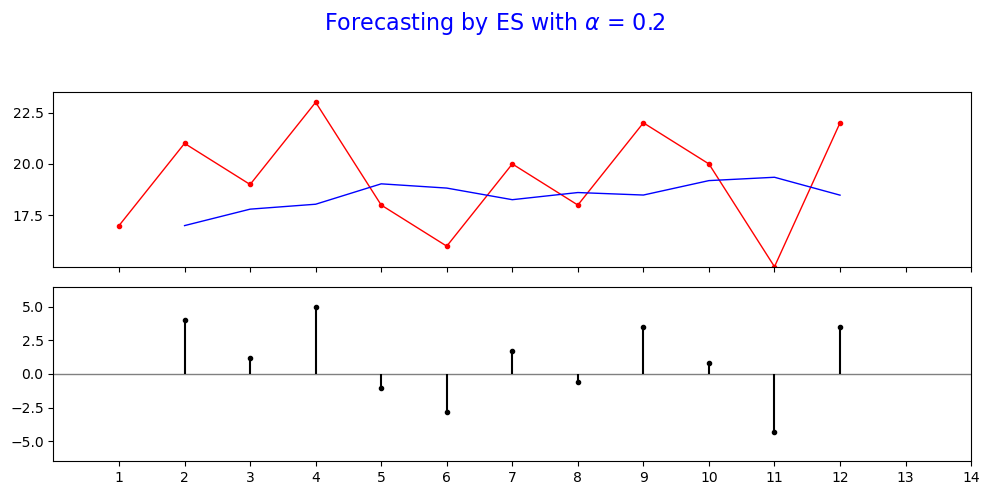

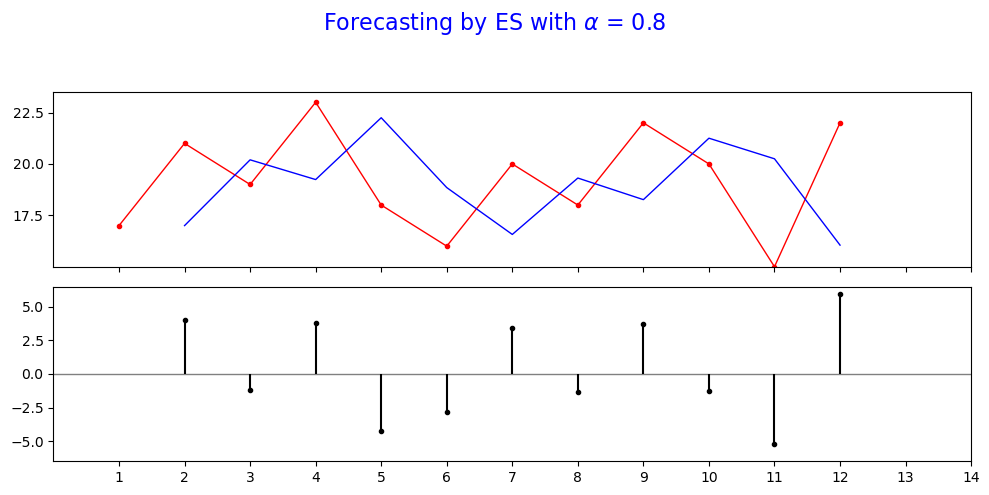

FORECAST COMPARISONS, 6 FORECASTS
Method                 ME    MAE    MAPE    MSE
------------------------------------------------------------------
Running Avg          0.35   2.20   11.88   6.69
Random Walk          1.00   4.00   20.74  19.00
Expert (E = 19)      0.50   2.17   11.58   6.17
ExpSmo (0.2)         0.77   2.42   12.85   7.95
ExpSmo (0.8)         0.88   3.49   18.29  15.33
ME = Mean Error
MAE = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE = Mean Squared Error


In [18]:
Y = y_gs1.astype(float).to_numpy()
t = weeks.astype(int).to_numpy()
Tn = len(Y)
k = 6  # last 6 forecasts

def exp_smoothing_forecast(y: np.ndarray, alpha: float) -> np.ndarray:
    es = np.empty_like(y, dtype=float)
    es[0] = y[0]
    for t in range(1, len(y)):
        es[t] = alpha * y[t - 1] + (1.0 - alpha) * es[t - 1]
    es[0] = np.nan
    return es

# Exponential smoothing with forecast errors
def exp_smoothing_forecast_errors(y, alpha):

    yhat = exp_smoothing_forecast(y, alpha)
    # Errors only defined for t>=2 in this convention
    u = np.empty_like(yhat)
    u[0] = np.nan
    u[1:] = y[1:] - yhat[1:]
    return yhat, u

def plot_es_assessment(y, tt, alpha, ax1, ax2):
    yhat, u = exp_smoothing_forecast_errors(y, alpha)

    # Top panel: sales and forecasts
    ax1.plot(tt, y, color="red", marker="o", linewidth=1.0, markersize=3)
    ax1.plot(tt, yhat, color="blue", linewidth=1.0)

    ax1.set_xlim(0, 14)
    ax1.set_ylim(15, 23.5)
    ax1.set_yticks([17.5, 20.0, 22.5])
    ax1.set_xticks(range(1, 15))
    ax1.set_xlabel("")
    ax1.set_ylabel("")
    ax1.grid(False)

    # Bottom panel: error indices
    ax2.axhline(0, color="gray", linewidth=1)
    ax2.vlines(tt[1:], 0, u[1:], color="black", linewidth=1.5)
    ax2.plot(tt[1:], u[1:], "ko", markersize=3)

    ax2.set_xlim(0, 14)
    ax2.set_ylim(-6.5, 6.5)
    ax2.set_yticks([-5.0, -2.5, 0.0, 2.5, 5.0])
    ax2.set_xticks(range(1, 15))
    ax2.set_xlabel("")
    ax2.set_ylabel("")
    ax2.grid(False)

    return yhat, u

# --- Figure: alpha = 0.2 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig.suptitle(rf"Forecasting by ES with $\alpha$ = 0.2", fontsize=16, color="blue", y=0.98)
yhat_02, u_02 = plot_es_assessment(Y, t, 0.2, ax1, ax2)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- Figure: alpha = 0.8 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig.suptitle(rf"Forecasting by ES with $\alpha$ = 0.8", fontsize=16, color="blue", y=0.98)
yhat_08, u_08 = plot_es_assessment(Y, t, 0.8, ax1, ax2)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- Metrics table: last 6 forecasts (t=T-5,...,T) for ES(0.2) and ES(0.8) ---
def metrics_last_k(y, u, k):
    u_last = u[-k:]
    y_last = y[-k:]
    metrics = forecast_metrics(u_last, y_last, tau=1)
    return metrics["ME"], metrics["MAE"], metrics["MAPE"], metrics["MSE"]
    # me = np.nanmean(u_last)
    # mae = np.nanmean(np.abs(u_last))
    # mape = np.nanmean(100.0 * np.abs(u_last) / np.abs(y_last))
    # mse = np.nanmean(u_last**2)
    # return me, mae, mape, mse

ME_run6, MAE_run6, MAPE_run6, MSE_run6 = metrics_last_k(Y, u_run, k)
ME_rw6,  MAE_rw6,  MAPE_rw6,  MSE_rw6  = metrics_last_k(Y, u_rw, k)
ME_exp6, MAE_exp6, MAPE_exp6, MSE_exp6 = metrics_last_k(Y, u_exp, k)
ME_02, MAE_02, MAPE_02, MSE_02 = metrics_last_k(Y, u_02, k)
ME_08, MAE_08, MAPE_08, MSE_08 = metrics_last_k(Y, u_08, k)


title = "FORECAST COMPARISONS, 6 FORECASTS"
line_eq = "=" * 66
line_dash = "-" * 66

print(title)
print(line_eq)
print(f"{'Method':<18}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>7}")
print(line_dash)

print(f"{'Running Avg':<18}{ME_run6:>7.2f}{MAE_run6:>7.2f}{MAPE_run6:>8.2f}{MSE_run6:>7.2f}")
print(f"{'Random Walk':<18}{ME_rw6:>7.2f}{MAE_rw6:>7.2f}{MAPE_rw6:>8.2f}{MSE_rw6:>7.2f}")
print(f"{'Expert (E = 19)':<18}{ME_exp6:>7.2f}{MAE_exp6:>7.2f}{MAPE_exp6:>8.2f}{MSE_exp6:>7.2f}")
print(f"{'ExpSmo (0.2)':<18}{ME_02:>7.2f}{MAE_02:>7.2f}{MAPE_02:>8.2f}{MSE_02:>7.2f}")
print(f"{'ExpSmo (0.8)':<18}{ME_08:>7.2f}{MAE_08:>7.2f}{MAPE_08:>8.2f}{MSE_08:>7.2f}")

print(line_eq)
print("ME = Mean Error")
print("MAE = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE = Mean Squared Error")

In [19]:
best_alpha, yhat_best, u_best = helper.estimate_alpha_exponential_smoothing(Y, criterion="MSE")

ME_est6, MAE_est6, MAPE_est6, MSE_est6 = metrics_last_k(Y, u_best, k)

print(f"{'ExpSmo (Est)':<18}{ME_est6:>7.2f}{MAE_est6:>7.2f}{MAPE_est6:>8.2f}{MSE_est6:>7.2f}")

ExpSmo (Est)         0.65   2.24   11.99   7.04


In [20]:
title = "FORECAST COMPARISONS, 6 FORECASTS"
line_eq = "=" * 70
line_dash = "-" * 70

print(title)
print(line_eq)
print(f"{'Method':<18}{'ME':>7}{'MAE':>7}{'MAPE':>8}{'MSE':>7}")
print(line_dash)

print(f"{'Running Avg':<18}{ME_run6:>7.2f}{MAE_run6:>7.2f}{MAPE_run6:>8.2f}{MSE_run6:>7.2f}")
print(f"{'Random Walk':<18}{ME_rw6:>7.2f}{MAE_rw6:>7.2f}{MAPE_rw6:>8.2f}{MSE_rw6:>7.2f}")
print(f"{'Expert (E = 19)':<18}{ME_exp6:>7.2f}{MAE_exp6:>7.2f}{MAPE_exp6:>8.2f}{MSE_exp6:>7.2f}")
print(f"{'ExpSmo (0.2)':<18}{ME_02:>7.2f}{MAE_02:>7.2f}{MAPE_02:>8.2f}{MSE_02:>7.2f}")
print(f"{'ExpSmo (0.8)':<18}{ME_08:>7.2f}{MAE_08:>7.2f}{MAPE_08:>8.2f}{MSE_08:>7.2f}")
print(f"{'ExpSmo (Est)':<18}{ME_est6:>7.2f}{MAE_est6:>7.2f}{MAPE_est6:>8.2f}{MSE_est6:>7.2f}")

print(line_eq)
print("ME   = Mean Error")
print("MAE  = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE  = Mean Squared Error")

FORECAST COMPARISONS, 6 FORECASTS
Method                 ME    MAE    MAPE    MSE
----------------------------------------------------------------------
Running Avg          0.35   2.20   11.88   6.69
Random Walk          1.00   4.00   20.74  19.00
Expert (E = 19)      0.50   2.17   11.58   6.17
ExpSmo (0.2)         0.77   2.42   12.85   7.95
ExpSmo (0.8)         0.88   3.49   18.29  15.33
ExpSmo (Est)         0.65   2.24   11.99   7.04
ME   = Mean Error
MAE  = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE  = Mean Squared Error


## GasolineSales2

### Forecasting different methods

Let $(Y_t)_{t=1}^T$ be weekly gasoline sales.

**Expert (constant) forecast**
$$
\hat Y_t^{E}=E,\qquad t=1,\dots,T.
$$

**Running average forecast**
$$
\bar Y_{t-1}=\frac{1}{t-1}\sum_{j=1}^{t-1}Y_j,\qquad 
\hat Y_t^{RA}=\bar Y_{t-1},\quad t=2,\dots,T.
$$

**Random walk forecast**
$$
\hat Y_t^{RW}=Y_{t-1},\qquad t=2,\dots,T.
$$

**AR(1) (expanding OLS, real-time)**
Estimate by OLS on $\{(Y_s,Y_{s-1})\}_{s=2}^{t-1}$:
$$
Y_s = c + \phi Y_{s-1} + \varepsilon_s,
$$
then forecast
$$
\hat Y_t^{AR1}=\hat c_{t-1}+\hat\phi_{t-1}Y_{t-1},\qquad t=3,\dots,T.
$$

**Exponential smoothing**
$$
\hat Y_{t}^{ES}=\alpha Y_{t-1}+(1-\alpha)\hat Y_{t-1}^{ES},\qquad
\hat Y_1^{ES}=Y_1,\quad t=2,\dots,T.
$$


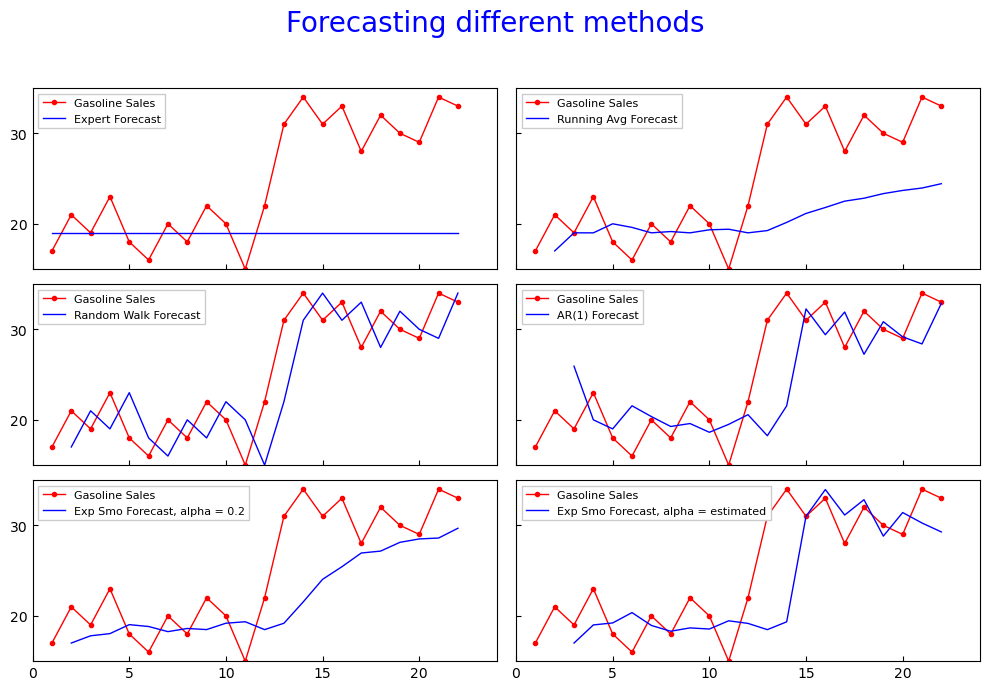

In [21]:
# ----------------------------
# Data input (GasolineSales2.xlsx as df2)
# ----------------------------
df2 = pd.read_excel("GasolineSales2.xlsx")
weeks2 = df2.iloc[:, 0].astype(int).to_numpy()
Y2 = df2.iloc[:, 1].astype(float).to_numpy()
T2 = len(Y2)

# ----------------------------
# Forecast methods
# ----------------------------
def running_average_forecast(y: np.ndarray) -> np.ndarray:
    ra = np.empty_like(y, dtype=float)
    ra[0] = np.nan
    csum = 0.0
    for i in range(len(y)):
        csum += y[i]
        if i >= 1:
            ra[i] = (csum - y[i]) / i
    return ra


def exp_smoothing_forecast(y: np.ndarray, alpha: float) -> np.ndarray:
    es = np.empty_like(y, dtype=float)
    es[0] = y[0]
    for t in range(1, len(y)):
        es[t] = alpha * y[t - 1] + (1.0 - alpha) * es[t - 1]
    es[0] = np.nan
    return es

def ar1_expanding_ols_forecast(y: np.ndarray) -> np.ndarray:
    ar1 = np.empty_like(y, dtype=float)
    ar1[:] = np.nan
    for t in range(2, len(y)):
        y_dep = y[1:t]
        x_lag = y[0:t-1]
        X = np.column_stack([np.ones_like(x_lag), x_lag])
        beta, _, _, _ = np.linalg.lstsq(X, y_dep, rcond=None)
        c_hat, phi_hat = beta[0], beta[1]
        ar1[t] = c_hat + phi_hat * y[t - 1]
    return ar1


# ----------------------------
# Compute forecasts
# ----------------------------
E = 19.0
f_expert = np.full_like(Y2, E, dtype=float)

f_runavg = running_average_forecast(Y2)
f_rw = lag_forecast(Y2)
f_ar1 = ar1_expanding_ols_forecast(Y2)
alpha_fixed = 0.2
f_es_02 = exp_smoothing_forecast(Y2, alpha_fixed)

alpha_est, yhat_best, u_best = helper.estimate_alpha_exponential_smoothing(Y2, criterion="MSE")
f_es_est = yhat_best

# ----------------------------
# Axis scaling 
# ----------------------------
x_left = 0
x_right = 24
x_ticks = np.arange(0, 25, 5)

y_bottom = 15
y_top = 35
y_ticks = [20, 30]

# ----------------------------
# Plot (3x2)
# ----------------------------
fig, axs = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True)
fig.suptitle("Forecasting different methods", fontsize=20, color="blue", y=0.98)

panels = [
    ("Expert Forecast", f_expert),
    ("Running Avg Forecast", f_runavg),
    ("Random Walk Forecast", f_rw),
    ("AR(1) Forecast", f_ar1),
    (rf"Exp Smo Forecast, alpha = {alpha_fixed:.1f}", f_es_02),
    ("Exp Smo Forecast, alpha = estimated", f_es_est),
]

for ax, (lab, f) in zip(axs.ravel(), panels):
    ax.plot(weeks2, Y2, color="red", marker="o", linewidth=1.0, markersize=3, label="Gasoline Sales")
    ax.plot(weeks2, f, color="blue", linewidth=1.0, label=lab)


    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

    ax.tick_params(direction="in")
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=8, frameon=True, fancybox=False, framealpha=1)

for ax in axs.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Forecast comparisons (16 one-step-ahead forecasts)

Let $U_t = Y_t - \hat Y_t$ be the one-step-ahead forecast error for $t=\tau,\dots,T$.
For a window of $N = T-\tau+1$ forecasts, define:

$$
\mathrm{ME} = \frac{1}{N}\sum_{t=\tau}^{T} U_t,
\qquad
\mathrm{MAE} = \frac{1}{N}\sum_{t=\tau}^{T} |U_t|,
$$

$$
\mathrm{MAPE} = \frac{100}{N}\sum_{t=\tau}^{T}\frac{|U_t|}{|Y_t|},
\qquad
\mathrm{MSE} = \frac{1}{N}\sum_{t=\tau}^{T} U_t^2.
$$

For “16 forecasts”, take $\tau = T-16+1$.


In [22]:
# Exponential smoothing with alpha = 0.8 (additional method for the table)
alpha_08 = 0.8
f_es_08 = exp_smoothing_forecast(Y2, alpha_08)

# ----------------------------
# Evaluation window: last 16 forecasts
# ----------------------------
N = 16
tau_idx = len(Y2) - N  # 0-based start index
Y_eval = Y2[tau_idx:]

def metrics(y_true: np.ndarray, y_hat: np.ndarray) -> tuple[float, float, float, float]:
    u = y_true - y_hat
    me = float(np.mean(u))
    mae = float(np.mean(np.abs(u)))
    mape = float(np.mean(100.0 * np.abs(u) / np.abs(y_true)))
    mse = float(np.mean(u**2))
    return me, mae, mape, mse

rows = [
    ("Running Avg", metrics(Y_eval, f_runavg[tau_idx:])),
    ("Random Walk", metrics(Y_eval, f_rw[tau_idx:])),
    ("Expert",      metrics(Y_eval, f_expert[tau_idx:])),
    ("ExpSmo (0.2)", metrics(Y_eval, f_es_02[tau_idx:])),
    ("ExpSmo (0.8)", metrics(Y_eval, f_es_08[tau_idx:])),
    ("ExpSmo (Est)", metrics(Y_eval, f_es_est[tau_idx:])),
]

# ----------------------------
# ASCII table 
# ----------------------------
title = "FORECAST COMPARISONS, 16 FORECASTS"
line_eq = "=" * 66
line_dash = "-" * 66

print(title)
print(line_eq)
print(f"{'Method':<16}{'ME':>10}{'MAE':>10}{'MAPE':>10}{'MSE':>10}")
print(line_dash)

for name, (me, mae, mape, mse) in rows:
    print(f"{name:<16}{me:>10.2f}{mae:>10.2f}{mape:>10.2f}{mse:>10.2f}")

print(line_eq)
print()
print("ME   = Mean Error")
print("MAE  = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE  = Mean Squared Error")

FORECAST COMPARISONS, 16 FORECASTS
Method                  ME       MAE      MAPE       MSE
------------------------------------------------------------------
Running Avg           5.88      6.57     22.50     59.63
Random Walk           1.06      3.69     14.77     18.06
Expert                8.00      8.62     28.99    102.38
ExpSmo (0.2)          3.78      4.40     15.63     32.29
ExpSmo (0.8)          1.28      3.44     13.63     17.82
ExpSmo (Est)          2.02      3.54     12.92     28.78

ME   = Mean Error
MAE  = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE  = Mean Squared Error


## Bicycle Sales

### Running Average Forecast

Let $\{Y_t\}_{t=1}^T$ be bicycle sales.

**Running average (real-time)**
$$
\bar Y_t=\frac{1}{t}\sum_{j=1}^{t}Y_j,\qquad t=1,\dots,T.
$$

**One-step-ahead running-average forecast**
$$
\hat Y_t^{F}=\bar Y_{t-1}=\frac{1}{t-1}\sum_{j=1}^{t-1}Y_j,\qquad t=2,\dots,T.
$$

**Constant-mean model**
$$
Y_t=\mu+\varepsilon_t,\qquad \mathbb{E}(\varepsilon_t)=0.
$$

**Unbiasedness of the running-average forecast under the constant-mean model**
$$
\mathbb{E}(\hat Y_t^{F})
=\mathbb{E}\!\left(\frac{1}{t-1}\sum_{j=1}^{t-1}Y_j\right)
=\frac{1}{t-1}\sum_{j=1}^{t-1}\mathbb{E}(Y_j)
=\frac{1}{t-1}\sum_{j=1}^{t-1}\mu
=\mu
=\mathbb{E}(Y_t).
$$


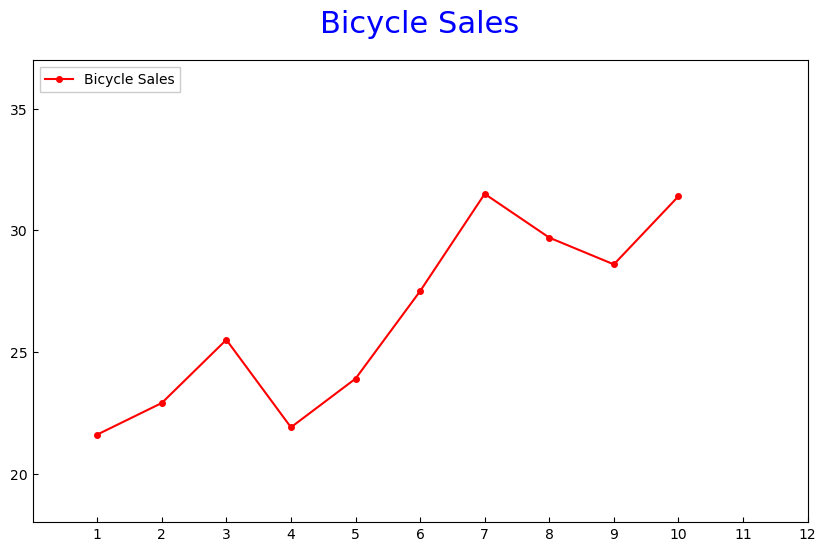

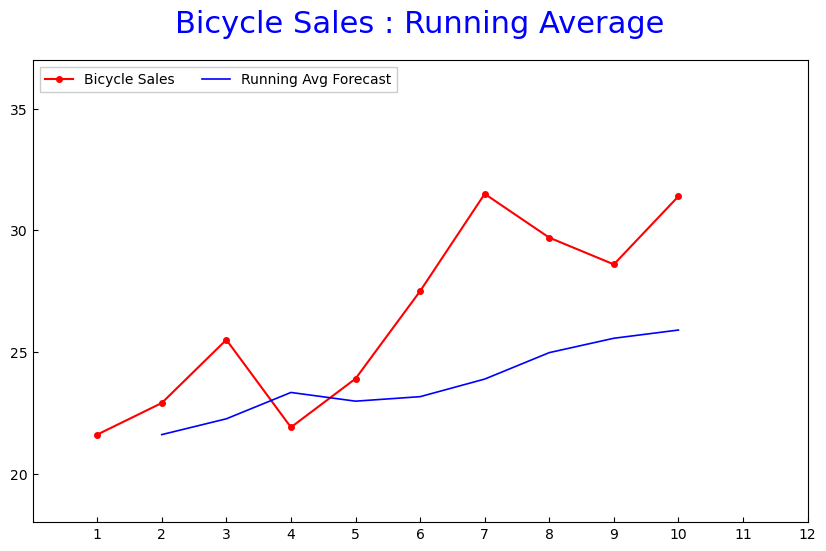

In [23]:
# ----------------------------
# Data input (BicycleSales.xlsx as df3)
# ----------------------------
df3 = pd.read_excel("BicycleSales.xlsx")
weeks3 = df3.iloc[:, 0].astype(int).to_numpy()
Y3 = df3.iloc[:, 1].astype(float).to_numpy()
T3 = len(Y3)

# ----------------------------
# Running-average forecast: \hat Y_t^F = \bar Y_{t-1}
# ----------------------------
running_avg3 = running_average_forecast(Y3)

# ----------------------------
# Axes settings
# ----------------------------
x_left = 0
x_right = int(max(weeks3) + 2)
x_ticks = np.arange(1, x_right + 1, 1)

y_bottom = 18
y_top = 37
y_ticks = [20, 25, 30, 35]

# ----------------------------
# Figure 1: Bicycle Sales
# ----------------------------
plt.figure(figsize=(10, 6))
plt.title("Bicycle Sales", fontsize=22, color="blue", pad=20)
plt.plot(weeks3, Y3, color="red", marker="o", linewidth=1.5, markersize=4, label="Bicycle Sales")
plt.xlim(x_left, x_right)
plt.ylim(y_bottom, y_top)
plt.xticks(x_ticks)
plt.yticks(y_ticks)
plt.tick_params(direction="in")
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, framealpha=1)
plt.xlabel("")
plt.ylabel("")
plt.show()

# ----------------------------
# Figure 2: Bicycle Sales : Running Average
# ----------------------------
plt.figure(figsize=(10, 6))
plt.title("Bicycle Sales : Running Average", fontsize=22, color="blue", pad=20)
plt.plot(weeks3, Y3, color="red", marker="o", linewidth=1.5, markersize=4, label="Bicycle Sales")
plt.plot(weeks3, running_avg3, color="blue", linewidth=1.2, label="Running Avg Forecast")
plt.xlim(x_left, x_right)
plt.ylim(y_bottom, y_top)
plt.xticks(x_ticks)
plt.yticks(y_ticks)
plt.tick_params(direction="in")
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, framealpha=1, ncol=2)
plt.xlabel("")
plt.ylabel("")
plt.show()


### Running Trend (expanding OLS)

Time-trend model:
$$
Y_t = \mu + \beta t + \varepsilon_t,
\qquad \mathbb{E}(\varepsilon_t)=0.
$$

Running Trend one-step-ahead forecast:
$$
\hat Y_t^{F}
=
\hat a_{t-1}
+
\hat b_{t-1}\,t,
\qquad
t = 3,\dots,T.
$$

At each time $t \ge 3$, estimate $(\mu,\beta)$ using past data $j=1,\dots,t-1$ by OLS:
$$
\begin{pmatrix}
\hat a_{t-1} \\
\hat b_{t-1}
\end{pmatrix}
=
\left(\sum_{j=1}^{t-1} x_j x_j^\top\right)^{-1}
\left(\sum_{j=1}^{t-1} x_j Y_j\right),
\qquad
x_j =
\begin{pmatrix}
1 \\
j
\end{pmatrix}.
$$

Equivalent closed-form expressions for slope and intercept:
$$
\hat b_{t-1}
=
\frac{\sum_{j=1}^{t-1}(j-\bar t_{t-1})Y_j}
     {\sum_{j=1}^{t-1}(j-\bar t_{t-1})^2},
\qquad
\hat a_{t-1}
=
\bar Y_{t-1}
-
\hat b_{t-1}\,\bar t_{t-1},
$$
where
$$
\bar t_{t-1}
=
\frac{1}{t-1}\sum_{j=1}^{t-1} j,
\qquad
\bar Y_{t-1}
=
\frac{1}{t-1}\sum_{j=1}^{t-1} Y_j.
$$


Below is the verification of the running (expanding) OLS trend and its
one-step-ahead forecast.

At each time $t \ge 3$, estimate the model using past data
$j = 1, \dots, t-1$:

$$
Y_j = \mu + \beta j + \varepsilon_j .
$$

Let $n = t-1$ and $x_j = j$.

#### 1. OLS and Normal Equations

OLS minimizes
$$
S(\mu,\beta)=\sum_{j=1}^{n}(Y_j-\mu-\beta x_j)^2 .
$$

First-order conditions:
$$
n\mu+\beta\sum x_j=\sum Y_j \tag{NE1}
$$
$$
\mu\sum x_j+\beta\sum x_j^2=\sum x_jY_j. \tag{NE2}
$$


#### 2. Intercept

Define sample means
$$
\bar x=\frac1n\sum x_j,\qquad \bar Y=\frac1n\sum Y_j .
$$

From (NE1):
$$
\mu=\bar Y-\beta\bar x
\quad\Rightarrow\quad
\hat a=\bar Y-\hat b\,\bar x .
$$

With $n=t-1$:
$$
\hat a_{t-1}=\bar Y_{t-1}-\hat b_{t-1}\bar t_{t-1}.
$$


#### 3. Slope

Substitute $\mu=\bar Y-\beta\bar x$ into (NE2):
$$
\beta
=
\frac{\sum x_jY_j-n\bar x\bar Y}{\sum x_j^2-n\bar x^2}
=
\frac{\sum (x_j-\bar x)(Y_j-\bar Y)}{\sum (x_j-\bar x)^2}.
$$

Hence
$$
\hat b_{t-1}
=
\frac{\sum_{j=1}^{t-1}(j-\bar t_{t-1})Y_j}
     {\sum_{j=1}^{t-1}(j-\bar t_{t-1})^2}.
$$


#### 4. Matrix Form

Let $x_j=(1,j)^\top$. Then
$$
\hat\theta=(\hat a,\hat b)^\top
=
\left(\sum x_jx_j^\top\right)^{-1}
\left(\sum x_jY_j\right),
$$
which is equivalent to the scalar formulas above.


#### 5. One-Step-Ahead Forecast

Given estimates from data up to $t-1$,
$$
\hat Y_t^F=\hat a_{t-1}+\hat b_{t-1}t .
$$

This is the running (expanding) linear trend forecast.


<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
C:\Users\georg\AppData\Local\Temp\ipykernel_24492\3407056610.py:5: SyntaxWarning: invalid escape sequence '\h'
  """


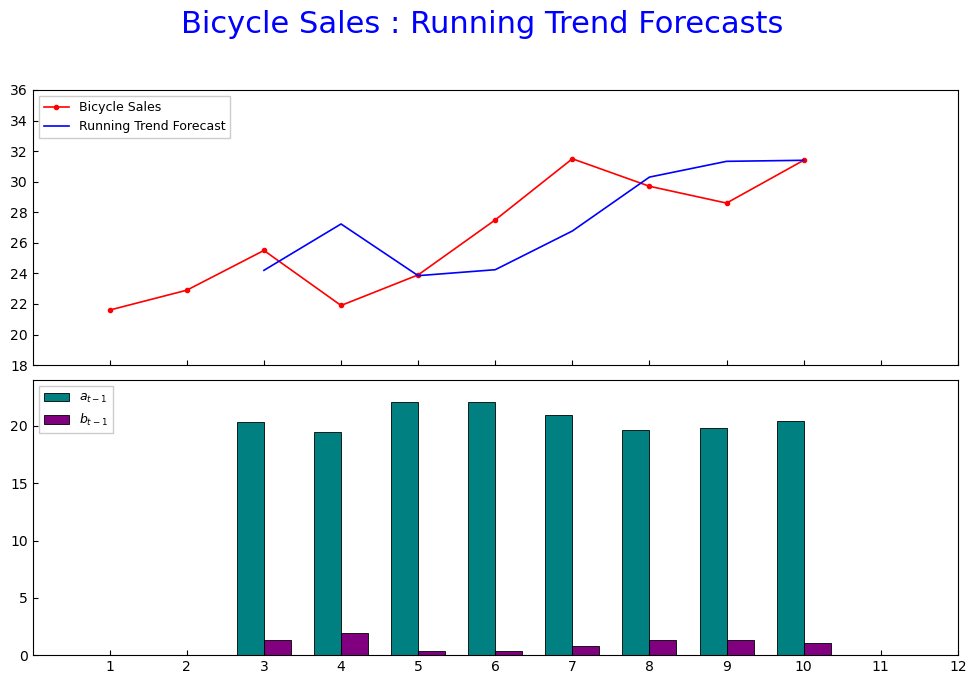

In [24]:
# ----------------------------
# Running Trend (expanding OLS) forecasts and coefficients
# ----------------------------
def running_trend_forecast(Y):
    """
    Running Trend (expanding-window OLS) forecast.

    Parameters
    ----------
    Y : array-like, shape (T,)
        Time series {Y_1, ..., Y_T}

    Returns
    -------
    forecast : np.ndarray, shape (T,)
        Running trend forecasts \hat Y_t^F
    a_hat : np.ndarray, shape (T,)
        Intercept estimates a_{t-1}
    b_hat : np.ndarray, shape (T,)
        Slope estimates b_{t-1}
    """
    Y = np.asarray(Y, dtype=float)
    T = len(Y)

    a_hat = np.full(T, np.nan)
    b_hat = np.full(T, np.nan)
    forecast = np.full(T, np.nan)

    for idx in range(2, T):  # need at least 2 past observations
        n = idx                    # uses Y[0] ... Y[idx-1]
        j = np.arange(1, n + 1)    # x_j = 1,...,t-1
        y_past = Y[:n]

        j_bar = j.mean()
        y_bar = y_past.mean()

        denom = np.sum((j - j_bar) ** 2)
        if denom == 0:
            continue

        b = np.sum((j - j_bar) * y_past) / denom
        a = y_bar - b * j_bar

        a_hat[idx] = a
        b_hat[idx] = b

        t_next = idx + 1            # 1-based time index
        forecast[idx] = a + b * t_next

    return forecast, a_hat, b_hat

running_trend3, a_hat, b_hat = running_trend_forecast(Y3)



# ----------------------------
# Figure
# ----------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True
)

fig.suptitle(
    "Bicycle Sales : Running Trend Forecasts",
    fontsize=22, color="blue", y=0.97
)

# ----------------------------
# Top panel
# ----------------------------
ax1.plot(weeks3, Y3, color="red", marker="o",
         linewidth=1.2, markersize=3,
         label="Bicycle Sales")

ax1.plot(weeks3, running_trend3, color="blue",
         linewidth=1.2,
         label="Running Trend Forecast")

ax1.set_xlim(0, 12)
ax1.set_ylim(18, 36)
ax1.set_xticks(np.arange(1, 13, 1))
ax1.tick_params(direction="in")
ax1.grid(False)
ax1.legend(loc="upper left",
           fontsize=9,
           frameon=True,
           fancybox=False,
           framealpha=1)

# ----------------------------
# Bottom panel
# ----------------------------
mask = ~np.isnan(a_hat)
x = weeks3[mask].astype(float)

bar_w = 0.35
ax2.bar(x - bar_w/2, a_hat[mask],
        width=bar_w,
        color="teal",
        edgecolor="black",
        linewidth=0.6,
        label=r"$a_{t-1}$")

ax2.bar(x + bar_w/2, b_hat[mask],
        width=bar_w,
        color="purple",
        edgecolor="black",
        linewidth=0.6,
        label=r"$b_{t-1}$")

ax2.set_xlim(0, 12)
ax2.set_ylim(0, 24)
ax2.set_xticks(np.arange(1, 13, 1))
ax2.tick_params(direction="in")
ax2.grid(False)
ax2.legend(loc="upper left",
           fontsize=9,
           frameon=True,
           fancybox=False,
           framealpha=1)

# ----------------------------
# Layout
# ----------------------------
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Moving Trend

In analogy with the Running Average, the **Moving Trend** generalizes the Moving Average
by allowing for a linear time trend over a rolling window.

We assume the time–trend model
$$
Y_t = \mu + \beta t + \varepsilon_t,
\qquad \mathbb{E}(\varepsilon_t)=0.
$$

The **Moving Trend** one–step–ahead forecast is
$$
\hat Y_t^{F} = \hat a^{\,m}_{t-1} + \hat b^{\,m}_{t-1}\, t,
$$
where the coefficients are estimated by OLS using the most recent $M$ observations
$(Y_t, Y_{t-1}, \dots, Y_{t-M+1})$.

The slope and intercept are given by
$$
\hat b^{\,m}_{t}
= \frac{\sum_{j=0}^{M-1}(t-j-\bar c_t^{\,m})Y_{t-j}}
       {\sum_{j=0}^{M-1}(t-j-\bar c_t^{\,m})^2},
\qquad
\hat a^{\,m}_{t}
= \bar Y_t^{\,m} - \hat b^{\,m}_{t}\,\bar c_t^{\,m},
$$
with
$$
\bar Y_t^{\,m} = \frac{1}{M}\sum_{j=0}^{M-1}Y_{t-j},
\qquad
\bar c_t^{\,m} = \frac{1}{M}\sum_{j=0}^{M-1}(t-j).
$$


### Verification of the Moving Trend Estimator

#### Model and window
Consider the time-trend model
$$
Y_s = \mu + \beta s + \varepsilon_s, \qquad \mathbb E[\varepsilon_s]=0.
$$

At time $t$, estimate the model on the moving window
$$
\{(t-j,\,Y_{t-j}) : j=0,\dots,M-1\}.
$$
Let
$$
x_j = t-j, \qquad y_j = Y_{t-j}.
$$

#### Least squares solution
The least squares problem minimizes
$$
\sum_{j=0}^{M-1} (y_j-a-bx_j)^2.
$$

Define window means
$$
\bar x = \frac1M\sum_{j=0}^{M-1} x_j,
\qquad
\bar y = \frac1M\sum_{j=0}^{M-1} y_j.
$$

From the normal equations,
$$
a = \bar y - b\bar x,
\qquad
b = \frac{\sum_{j=0}^{M-1}(x_j-\bar x)(y_j-\bar y)}
{\sum_{j=0}^{M-1}(x_j-\bar x)^2}.
$$

Since
$$
\sum_{j=0}^{M-1}(x_j-\bar x)=0,
$$
it follows that
$$
\sum_{j=0}^{M-1}(x_j-\bar x)(y_j-\bar y)
=
\sum_{j=0}^{M-1}(x_j-\bar x)y_j.
$$

Define
$$
\bar Y_t^m = \frac1M\sum_{j=0}^{M-1} Y_{t-j},
\qquad
c_t^m = \frac1M\sum_{j=0}^{M-1}(t-j).
$$

Then $\bar x=c_t^m$, $\bar y=\bar Y_t^m$, and
$$
b_t^m
=
\frac{\sum_{j=0}^{M-1}\bigl((t-j)-c_t^m\bigr)Y_{t-j}}
{\sum_{j=0}^{M-1}\bigl((t-j)-c_t^m\bigr)^2},
\qquad
a_t^m = \bar Y_t^m - b_t^m c_t^m.
$$


#### Forecast
Using the window ending at $t-1$, the moving-trend forecast is
$$
\hat Y_t^{\,F} = a_{t-1}^m + b_{t-1}^m\, t.
$$

All expressions coincide with the stated results.



---

### Random Walk Plus Drift

The standard Random Walk model is
$$
Y_t = Y_{t-1} + \varepsilon_t,
\qquad
\hat Y_t^{F}=Y_{t-1}.
$$

To account for trending behavior, we introduce a **drift**:
$$
Y_t = \mu + Y_{t-1} + \varepsilon_t,
\qquad
\hat Y_t^{F}=Y_{t-1} + c_{t-1}.
$$

The drift term is estimated as the sample mean of first differences:
$$
c_t
= \frac{1}{t-1}\sum_{j=0}^{t-2}(Y_{t-j}-Y_{t-j-1})
= \frac{1}{t-1}\sum_{j=0}^{t-2}\Delta Y_{t-j}.
$$


### Estimation of the drift

Rewrite the model in first differences:
$$
\Delta Y_t = Y_t - Y_{t-1} = \mu + \varepsilon_t.
$$
Thus, $\Delta Y_t$ is a mean–zero process shifted by $\mu$, and
$$
\mathbb E(\Delta Y_t) = \mu.
$$

A natural estimator of $\mu$ is therefore the sample mean of past differences. Using observations up to time $t-1$,
$$
c_t
= \frac{1}{t-1}\sum_{j=0}^{t-2}(Y_{t-j} - Y_{t-j-1})
= \frac{1}{t-1}\sum_{j=0}^{t-2}\Delta Y_{t-j}.
$$


### Forecast with estimated drift

Substituting $\mu$ by its estimator $c_{t-1}$ yields the Random Walk Plus Drift forecast
$$
\hat Y_t^{F} = Y_{t-1} + c_{t-1}.
$$




---

### Forecast Evaluation

For forecasts $\hat Y_t^{F}$ and forecast errors $U_t = Y_t - \hat Y_t^{F}$,
the following accuracy measures are commonly used.

- **ME** (Mean Error):
$$
\text{ME} = \frac{1}{n}\sum U_t
$$

- **MAE** (Mean Absolute Error):
$$
\text{MAE} = \frac{1}{n}\sum |U_t|
$$

- **MAPE** (Mean Absolute Percentage Error):
$$
\text{MAPE} = \frac{100}{n}\sum \frac{|U_t|}{|Y_t|}
$$

- **MSE** (Mean Squared Error):
$$
\text{MSE} = \frac{1}{n}\sum U_t^2
$$



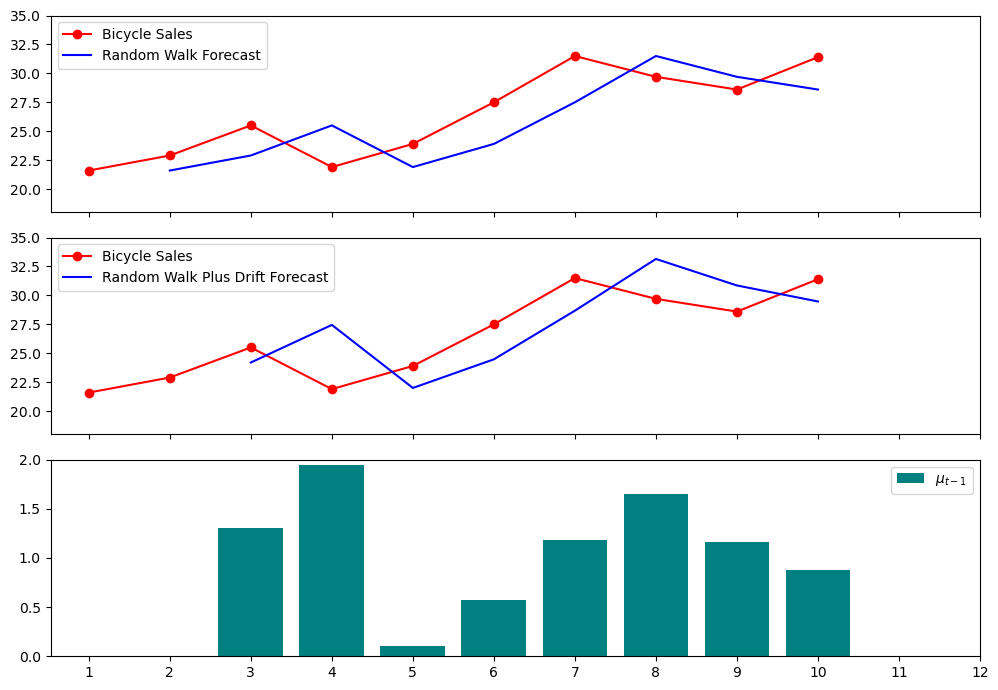

In [25]:
def random_walk_plus_drift_forecast(Y):
    """
    Random Walk Plus Drift (expanding-window) one-step-ahead forecast.

    Parameters
    ----------
    Y : array-like, shape (T,)
        Time series {Y_1, ..., Y_T}

    Returns
    -------
    rw : np.ndarray, shape (T,)
        Random walk forecasts (no drift): Y_hat_t = Y_{t-1}

    rw_drift : np.ndarray, shape (T,)
        Random walk plus drift forecasts

    mu_hat : np.ndarray, shape (T,)
        Estimated drift parameters mu_hat_{t-1}
    """
    Y = np.asarray(Y, dtype=float)
    T = len(Y)

    # ----------------------------
    # Random walk forecast (no drift)
    # ----------------------------
    rw = np.full(T, np.nan)
    rw[1:] = Y[:-1]

    # ----------------------------
    # Drift estimation (expanding window)
    # ----------------------------
    dY = np.diff(Y)  # Delta Y_t = Y_t - Y_{t-1}
    mu_hat = np.full(T, np.nan)

    for t in range(2, T):
        # Uses differences Delta Y_2, ..., Delta Y_{t-1}
        mu_hat[t] = dY[:t-1].mean()

    # ----------------------------
    # Random walk plus drift forecast
    # ----------------------------
    rw_drift = np.full(T, np.nan)
    for t in range(2, T):
        rw_drift[t] = Y[t-1] + mu_hat[t]

    return rw, rw_drift, mu_hat

rw3, rw_drift3, mu_hat = random_walk_plus_drift_forecast(Y3)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Random walk
axes[0].plot(weeks3, Y3, color="red", marker="o", label="Bicycle Sales")
axes[0].plot(weeks3, rw3, color="blue", label="Random Walk Forecast")
axes[0].set_ylim(18, 35)
axes[0].legend()

# Random walk plus drift
axes[1].plot(weeks3, Y3, color="red", marker="o", label="Bicycle Sales")
axes[1].plot(weeks3, rw_drift3, color="blue", label="Random Walk Plus Drift Forecast")
axes[1].set_ylim(18, 35)
axes[1].legend()

# Drift estimates
mask = ~np.isnan(mu_hat)
axes[2].bar(weeks3[mask], mu_hat[mask], color="teal", label=r"$\mu_{t-1}$")
axes[2].set_ylim(0, 2)
axes[2].legend()

axes[2].set_xticks(np.arange(1, 13, 1))

plt.tight_layout()
plt.show()


In [26]:
# ----------------------------
# Evaluation on last 6 periods
# ----------------------------
N = 6
tau_idx = len(Y3) - N  # 0-based start index

rows = {
    "Running Avg": metrics(Y3[tau_idx:], running_avg3[tau_idx:]),
    "Running Trend": metrics(Y3[tau_idx:], running_trend3[tau_idx:]),
    "Random Walk": metrics(Y3[tau_idx:], rw3[tau_idx:]),
    "Random Walk Plus Drift": metrics(Y3[tau_idx:], rw_drift3[tau_idx:]),
}

table = pd.DataFrame(rows).T.round(2)

print("FORECAST COMPARISONS, 6 FORECASTS")
print("="*50)
print(table.to_string())
print("="*50)
print("ME   = Mean Error")
print("MAE  = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE  = Mean Squared Error")


FORECAST COMPARISONS, 6 FORECASTS
                           0     1      2      3
Running Avg             4.36  4.36  14.65  23.26
Running Trend           0.78  1.89   6.44   6.80
Random Walk             1.58  2.55   8.83   7.54
Random Walk Plus Drift  0.66  2.56   8.92   6.90
ME   = Mean Error
MAE  = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE  = Mean Squared Error


### Holt–Winters (Double Exponential Smoothing) 

Let $\{Y_t\}_{t=1}^T$ be a time series with a linear trend.

### Single Exponential Smoothing (SES)

$$
\hat{Y}_{t+1}^{(F)} = \alpha Y_t + (1-\alpha)\hat{Y}_t^{(F)},
\qquad 0 < \alpha \le 1
$$

### Holt–Winters / Double Exponential Smoothing (DES)

**State variables**

- Level: $L_t$
- Trend (growth): $G_t$

**Recursions**

$$
\begin{aligned}
L_t &= \alpha Y_t + (1-\alpha)(L_{t-1}+G_{t-1}), \\
G_t &= \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1}, \\
\hat{Y}_{t+1}^{(F)} &= L_t + G_t,
\end{aligned}
\qquad t = 2,\ldots,T
$$

**Initialization**

$$
L_1 = Y_1,
\qquad
G_1 = Y_2 - Y_1
$$

**Parameter constraints**

$$
0 < \alpha \le 1, \qquad 0 < \beta \le 1
$$

- $\alpha$: controls responsiveness of the level  
- $\beta$: controls responsiveness of the trend (typically smaller)


### Observation Weights for Holt’s Linear Trend Model

For Holt’s (double exponential smoothing) model with parameters  
$0 < \alpha \le 1$, $0 < \beta \le 1$, consider the one–step–ahead forecast
$$
\hat Y_t = L_{t-1} + G_{t-1}.
$$

Because the model is linear, the forecast can be written as a weighted sum of past observations:
$$
\hat Y_t = \sum_{k \ge 1} w_k\, Y_{t-k},
$$
where $w_k$ are the observation weights.

### State–space representation

Define the state vector $s_t = (L_t, G_t)^\top$. The Holt recursions can be written as
$$
s_t = A s_{t-1} + b Y_t,
$$
with
$$
A =
\begin{pmatrix}
1-\alpha & 1-\alpha \\
-\beta\alpha & 1-\beta\alpha
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
\alpha \\
\beta\alpha
\end{pmatrix}.
$$

The forecast is
$$
\hat Y_{t+1} = c^\top s_t,
\qquad
c =
\begin{pmatrix}
1 \\
1
\end{pmatrix}.
$$

### Closed–form expression

The weight of $Y_{t-k}$ in the forecast is given by the impulse response
$$
w_k = c^\top A^{k-1} b,
\qquad k \ge 1.
$$

### Recursive form

The weights satisfy a second–order linear recurrence
$$
w_{k+2} = (2 - \alpha - \beta\alpha)\, w_{k+1}
        - (1 - \alpha)\, w_k,
\qquad k \ge 1.
$$

The initial weights are
$$
\begin{aligned}
w_1 &= \alpha(1+\beta), \\
w_2 &= \alpha(1+2\beta) - \alpha^2(1+\beta)^2.
\end{aligned}
$$

These formulas show that Holt’s forecast acts as a linear filter whose weights depend only on
$(\alpha,\beta)$. The shape of the sequence $\{w_k\}$ is governed by the eigenvalues of the state
transition matrix $A$.


For **Holt–Winters without seasonality** (or **double exponential smoothing**), the one–step forecast is

$$
\hat y_{t+1} = L_t + G_t
$$

with updates

$$
L_t = \alpha y_t + (1-\alpha)(L_{t-1}+G_{t-1})
$$

$$
G_t = \beta(L_t-L_{t-1}) + (1-\beta)G_{t-1}
$$

Because these recursions are **linear**, the forecast can be written as a weighted sum of past observations:

$$
\hat y_{t+1} = \sum_{k=0}^{\infty} w_k y_{t-k}
$$

* $w_0$ is the weight on the most recent observation $y_t$,
* $w_1$ is the weight on $y_{t-1}$,
* etc.

The plot is the **impulse response** of the forecasting filter: set a single observation to $1$ (an impulse) and all others to $0$, then track how the one-step forecast evolves; that sequence equals the weights $w_k$.

### Interpreting the panels

* Larger $\alpha$ $\rightarrow$ heavier weight on very recent data (big first bar, fast decay).
* Larger $\beta$ $\rightarrow$ trend reacts more; weights can **alternate sign** (overshoot/compensation), creating negative bars.
* Small $(\alpha,\beta)$ $\rightarrow$ smoother, longer memory; weights decay slowly.

That’s why:

* $(0.7,0.2)$: very spiky at small lags, then quickly near zero.
* $(0.2,0.7)$: strong oscillation (positive then negative then positive).
* $(0.7,0.7)$: strong immediate reaction + quick correction.

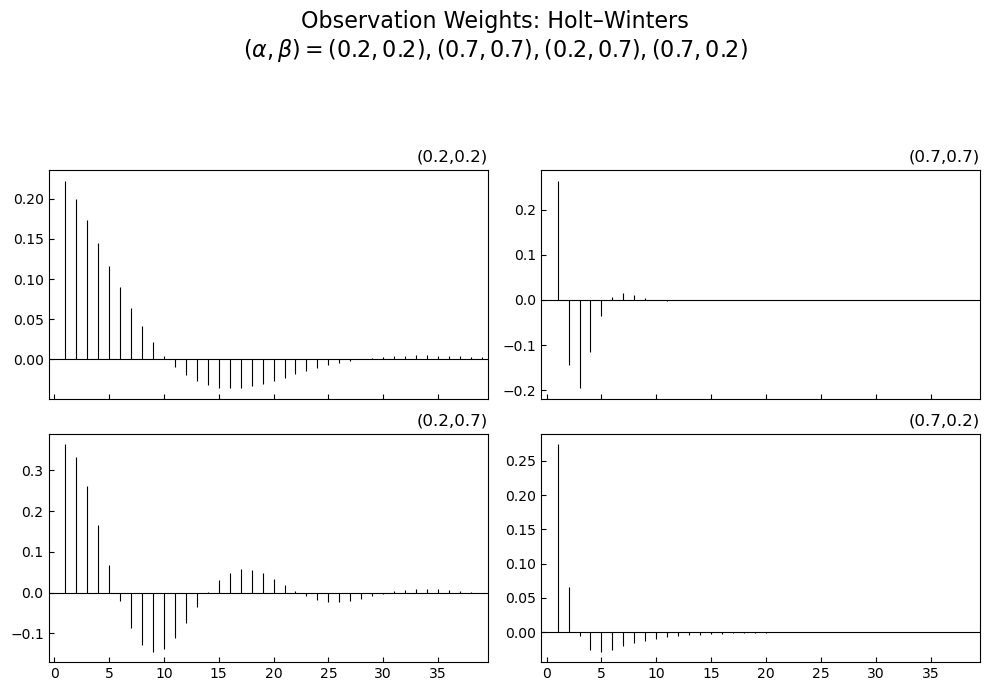

In [27]:
def holt_forecast_from_series(y, alpha, beta):
    """
    Holt with:
      L1 = Y1
      G1 = Y2 - Y1
    Returns the one-step-ahead forecast after consuming all y: F_{T+1} = L_T + G_T
    """
    y = np.asarray(y, dtype=float)
    if len(y) < 2:
        raise ValueError("Need at least two observations")

    L = y[0]            # L1
    G = y[1] - y[0]     # G1

    for yt in y[1:]:
        L_prev = L
        L = alpha * yt + (1 - alpha) * (L + G)
        G = beta * (L - L_prev) + (1 - beta) * G

    return L + G


def holt_observation_weights(alpha, beta, max_lag=40, burn=200):
    """
    lag 0 corresponds to Y_{t-1} (forecast formed using data up to t-1),
    not Y_t.
    """
    # choose a time index far from initialization
    t = burn + max_lag + 1

    # series ends at (t-1), length = t
    T = t

    weights = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        y = np.zeros(T)
        y[(t - 1) - k] = 1.0  # impulse at Y_{t-1-k}
        weights[k] = holt_forecast_from_series(y, alpha, beta)  # forecast for time t
    return weights


pairs = [(0.2, 0.2), (0.7, 0.7), (0.2, 0.7), (0.7, 0.2)]
max_lag = 40

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

for ax, (a, b) in zip(axes.ravel(), pairs):
    w = holt_observation_weights(a, b, max_lag=max_lag, burn=250)

    # Drop the first weight
    w_plot = w[1:]
    x = np.arange(1, len(w_plot) + 1)  
    

    ax.axhline(0, linewidth=0.8, color="black")
    ax.vlines(x, 0, w_plot, linewidth=0.8, color="black")
    ax.set_xlim(-0.5, len(w_plot) - 0.5)
    ax.set_title(f"({a},{b})", loc="right")
    ax.tick_params(direction="in")


fig.suptitle("Observation Weights: Holt–Winters\n"
             r"$(\alpha,\beta)=(0.2,0.2),(0.7,0.7),(0.2,0.7),(0.7,0.2)$",
             fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


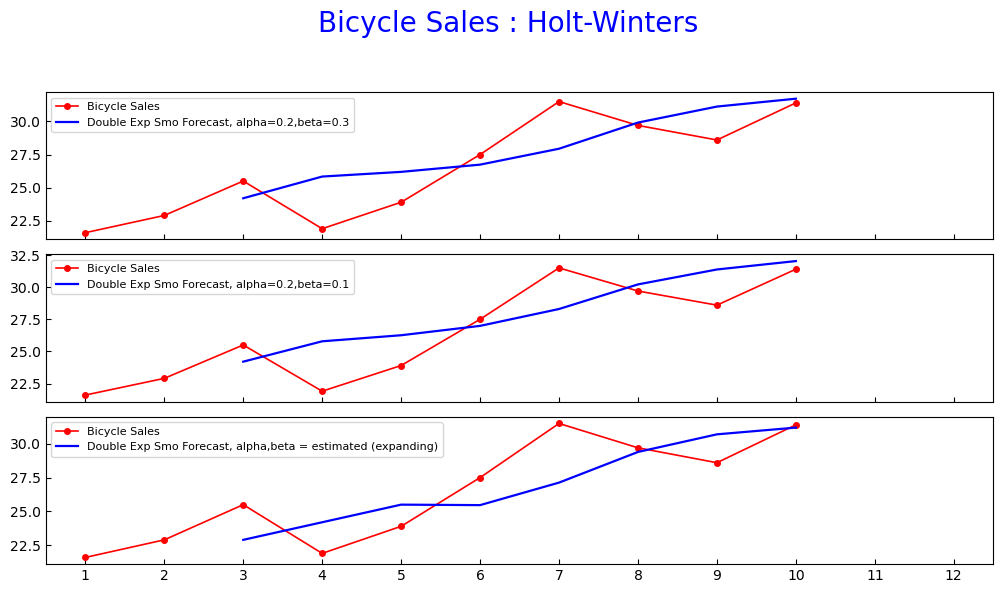

Estimated alpha (last) = 0.041, beta (last) = 0.999


In [28]:
# -----------------------------
# Load data
# -----------------------------
df3 = pd.read_excel("BicycleSales.xlsx")
Y3 = df3.iloc[:, 1].astype(float).to_numpy()
T3 = len(Y3)
x = np.arange(1, T3 + 1)


# -----------------------------
# Holt (Double Exponential Smoothing)
# (kept locally so the fixed (alpha,beta) lines still work)
# -----------------------------
def holt_fitted_forecast_series(y, alpha, beta):
    y = np.asarray(y, dtype=float)

    L = y[0]          # L1
    G = y[1] - y[0]   # G1

    F = np.full(len(y), np.nan)
    F[0] = y[0]

    for t in range(1, len(y)):
        F[t] = L + G
        L_prev = L
        L = alpha * y[t] + (1 - alpha) * (L + G)
        G = beta * (L - L_prev) + (1 - beta) * G

    return F


# -----------------------------
# Forecasts
# -----------------------------
F_02_03 = holt_fitted_forecast_series(Y3, alpha=0.2, beta=0.3)
F_02_01 = holt_fitted_forecast_series(Y3, alpha=0.2, beta=0.1)

alpha_path, beta_path, F_hat, u_hat, loss_path = helper.estimate_alpha_beta_holt_winters(
    Y3,
    criterion="SSE",
    grid_n=201,
    eps=1e-3,
)

# ALL forecasts start from t = 3
for F in (F_02_03, F_02_01, F_hat):
    F[:2] = np.nan


# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

panels = [
    (F_02_03, r"Double Exp Smo Forecast, alpha=0.2,beta=0.3"),
    (F_02_01, r"Double Exp Smo Forecast, alpha=0.2,beta=0.1"),
    (F_hat,   r"Double Exp Smo Forecast, alpha,beta = estimated (expanding)"),
]

for ax, (F_line, label_blue) in zip(axes, panels):
    ax.plot(x, Y3, "o-", color="red", linewidth=1.2, markersize=4,
            label="Bicycle Sales")
    ax.plot(x, F_line, "-", color="blue", linewidth=1.6,
            label=label_blue)

    ax.set_xlim(0.5, 12.5)
    ax.legend(loc="upper left", frameon=True, fontsize=8)
    ax.tick_params(direction="in")

axes[-1].set_xticks(np.arange(1, 13))

fig.suptitle("Bicycle Sales : Holt-Winters",
             fontsize=20, color="blue", y=0.98)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


# -----------------------------
# Print "final" estimated params (last available step)
# -----------------------------
valid = ~np.isnan(alpha_path) & ~np.isnan(beta_path)
if np.any(valid):
    a_hat = alpha_path[valid][-1]
    b_hat = beta_path[valid][-1]
    print(f"Estimated alpha (last) = {a_hat:.3f}, beta (last) = {b_hat:.3f}")
else:
    print("Estimated alpha/beta not available (series too short).")


In [29]:
def metrics_row(y, yhat, start_idx):
    me, mae, mape, mse = metrics(y[start_idx:], yhat[start_idx:])
    return {"ME": me, "MAE": mae, "MAPE": mape, "MSE": mse}

# ----------------------------
# Forecasts
# ----------------------------
# Exp smoothing (fixed alphas)
F_exp_02 = exp_smoothing_forecast(Y3, alpha=0.2)
F_exp_08 = exp_smoothing_forecast(Y3, alpha=0.8)

# Exp smoothing (expanding re-fit alpha each step)
alpha_exp_path, F_exp_hat, u_exp_hat = helper.estimate_alpha_exponential_smoothing(Y3, criterion="MSE")

# Double exp (Holt) fixed params
F_02_01 = holt_fitted_forecast_series(Y3, alpha=0.2, beta=0.1)
F_02_03 = holt_fitted_forecast_series(Y3, alpha=0.2, beta=0.3)

# Double exp (Holt) expanding re-fit alpha/beta each step
alpha_holt_path, beta_holt_path, F_hat, u_holt_hat, loss_holt_path = helper.estimate_alpha_beta_holt_winters(
    Y3, criterion="SSE", grid_n=201, eps=1e-3
)

for F in (F_02_01, F_02_03, F_hat):
    F[:2] = np.nan

# Optional: enforce comparable start for ES too (since ES/metrics conventions often start at t>=2)
for F in (F_exp_02, F_exp_08, F_exp_hat):
    F[:1] = np.nan

# ----------------------------
# Evaluation on last 6 periods
# ----------------------------
N = 6
tau_idx = len(Y3) - N  # 0-based start index of last 6 observations

rows = {
    "Exp Smo (0.2)"            : metrics_row(Y3, F_exp_02, tau_idx),
    "Exp Smo (0.8)"            : metrics_row(Y3, F_exp_08, tau_idx),
    "Exp Smo (Est, expanding)" : metrics_row(Y3, F_exp_hat, tau_idx),
    "Double Exp Smo (0.2,0.1)" : metrics_row(Y3, F_02_01, tau_idx),
    "Double Exp Smo (0.2,0.3)" : metrics_row(Y3, F_02_03, tau_idx),
    "Double Exp Smo (Est, expanding)" : metrics_row(Y3, F_hat, tau_idx),
}

table = pd.DataFrame(rows).T.round(2)

print("FORECAST COMPARISONS, 6 FORECASTS")
print("=" * 60)
print(table.to_string())
print("=" * 60)
print("ME   = Mean Error")
print("MAE  = Mean Absolute Error")
print("MAPE = Mean Absolute Percentage Error")
print("MSE  = Mean Squared Error")

# Print last available estimated parameters (paths)
valid_exp = ~np.isnan(alpha_exp_path)
if np.any(valid_exp):
    a_exp_last = alpha_exp_path[valid_exp][-1]
    print(f"Estimated alpha (Exp Smo, last) = {a_exp_last:.3f}")

valid_holt = ~np.isnan(alpha_holt_path) & ~np.isnan(beta_holt_path)
if np.any(valid_holt):
    a_holt_last = alpha_holt_path[valid_holt][-1]
    b_holt_last = beta_holt_path[valid_holt][-1]
    print(f"Estimated alpha (Holt, last) = {a_holt_last:.3f}, beta (Holt, last) = {b_holt_last:.3f}")


FORECAST COMPARISONS, 6 FORECASTS
                                   ME   MAE   MAPE    MSE
Exp Smo (0.2)                    4.28  4.28  14.48  22.37
Exp Smo (0.8)                    1.75  2.45   8.42   8.10
Exp Smo (Est, expanding)         2.46  3.43  11.64  17.45
Double Exp Smo (0.2,0.1)        -0.43  1.67   5.89   4.07
Double Exp Smo (0.2,0.3)        -0.17  1.61   5.70   4.17
Double Exp Smo (Est, expanding)  0.54  1.77   6.16   5.06
ME   = Mean Error
MAE  = Mean Absolute Error
MAPE = Mean Absolute Percentage Error
MSE  = Mean Squared Error
Estimated alpha (Exp Smo, last) = 1.000
Estimated alpha (Holt, last) = 0.041, beta (Holt, last) = 0.999


## Umbrella Sales

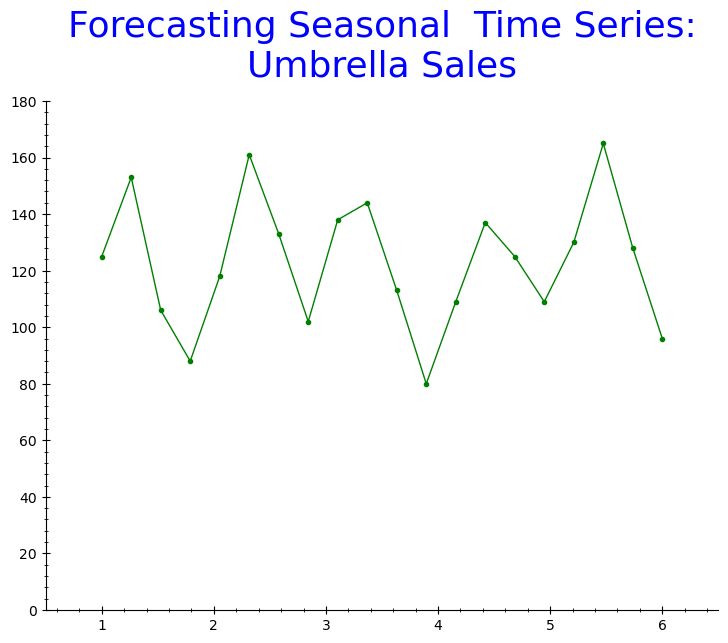

In [30]:
# --- load data (df4) ---
df4 = pd.read_excel("Umbrella.xlsx")
y4 = df4.select_dtypes(include="number").iloc[:, 1].to_numpy()

# x from 1 to 6 (18 seasonal points -> matches the shown axis style)
x = np.linspace(1, 6, len(y4))

# --- plot ---
fig, ax = plt.subplots(figsize=(8.68, 6.61), dpi=100)

ax.plot(
    x, y4,
    color="green",
    marker="o",
    markersize=3,
    linewidth=1
)

ax.set_title("Forecasting Seasonal  Time Series:\nUmbrella Sales",
             color="blue", fontsize=26, pad=18)

# axes limits + ticks to match
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0, 180)
ax.set_xticks(np.arange(1, 7, 1))
ax.set_yticks(np.arange(0, 181, 20))

# minor ticks similar to the figure
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# show only left/bottom spines (like the image)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(which="major", length=6, direction="inout")
ax.tick_params(which="minor", length=3, direction="inout")

plt.show()


In [31]:
df4

,Unnamed: 0,SeasIdx,Umbrella Sales
0,1(1),1,125
1,1(2),2,153
2,1(3),3,106
3,1(4),4,88
4,2(1),1,118
5,2(2),2,161
6,2(3),3,133
7,2(4),4,102
8,3(1),1,138
9,3(2),2,144


### Seasonal Time Series Forecasting – Summary

### 1. Seasonal Random Walk (SRW)

Model  
$$
Y_t = Y_{t-S} + \varepsilon_t, \qquad \mathbb{E}(\varepsilon_t)=0
$$

Forecast  
$$
\hat Y_t = Y_{t-S}
$$

Idea: the series repeats its value from the same season in the previous cycle.  
Use case: strong seasonality, no trend.

### 2. Seasonal Random Walk with Drift

Model  
$$
Y_t = \mu + Y_{t-S} + \varepsilon_t
$$

Forecast  
$$
\hat Y_t = c_{t-1} + Y_{t-S}
$$

Drift estimate  
$$
c_t = \frac{1}{t-1}\sum_{j=0}^{t-S-1}(Y_{t-j}-Y_{t-j-S})
$$

Idea: allows a slow seasonal trend in addition to repetition.

### 3. Running Seasonal Regression

Model with seasonal dummies  
$$
Y_t = \mu + \beta t + \sum_{j=1}^S \gamma_j D_{jt} + \varepsilon_t
$$

Constraint to avoid multicollinearity  
$$
\sum_{j=1}^S \gamma_j = 0
$$

Forecast  
$$
\hat Y_t = a_{t-1} + b_{t-1}t + \sum_{j=1}^S g_{j,t-1} D_{jt}
$$

Idea: linear trend plus seasonal effects, updated recursively.

### 4. Seasonal Holt–Winters Methods

Decomposes the series into  
$$
\text{Level } (L_t), \quad \text{Growth } (G_t), \quad \text{Seasonal factor } (H_t)
$$

#### 4.1 Multiplicative Seasonality

Update equations  
$$
L_t = \alpha \frac{Y_t}{H_{t-S}} + (1-\alpha)(L_{t-1}+G_{t-1})
$$
$$
G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1}
$$
$$
H_t = \gamma \frac{Y_t}{L_t} + (1-\gamma)H_{t-S}
$$

Forecast  
$$
\hat Y_{t+1} = H_{t-S+1}(L_t + G_t)
$$

Use case: seasonal amplitude grows with the level.

#### 4.2 Additive Seasonality

Update equations  
$$
L_t = \alpha (Y_t - H_{t-S}) + (1-\alpha)(L_{t-1}+G_{t-1})
$$
$$
G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1}
$$
$$
H_t = \gamma (Y_t - L_t) + (1-\gamma)H_{t-S}
$$

Forecast  
$$
\hat Y_{t+1} = L_t + G_t + H_{t-S+1}
$$

Use case: seasonal amplitude is roughly constant.

### 5. Initialization

Initial level  
$$
L_S = \frac{1}{S}\sum_{j=1}^S Y_j
$$

Initial growth  
$$
G_S = \frac{1}{S}\left(\frac{1}{S}\sum_{j=S+1}^{2S} Y_j - L_S\right)
$$

Seasonal factors  
$$
H_j = \frac{Y_j}{L_S} \quad \text{(multiplicative)}, \qquad
H_j = Y_j - L_S \quad \text{(additive)}
$$

### 6. Method Comparison

SRW: seasonality only  
SRW with drift: seasonality plus slow growth  
Seasonal regression: interpretable trend and seasonal effects  
Holt–Winters additive: constant seasonal size  
Holt–Winters multiplicative: seasonal size proportional to level


Time Series Decomposition (separating the data into Trend, Seasonal, and Residual components). Since the seasonal waves fluctuate around 0 (rather than 1), it is an Additive Decomposition.

### Using library

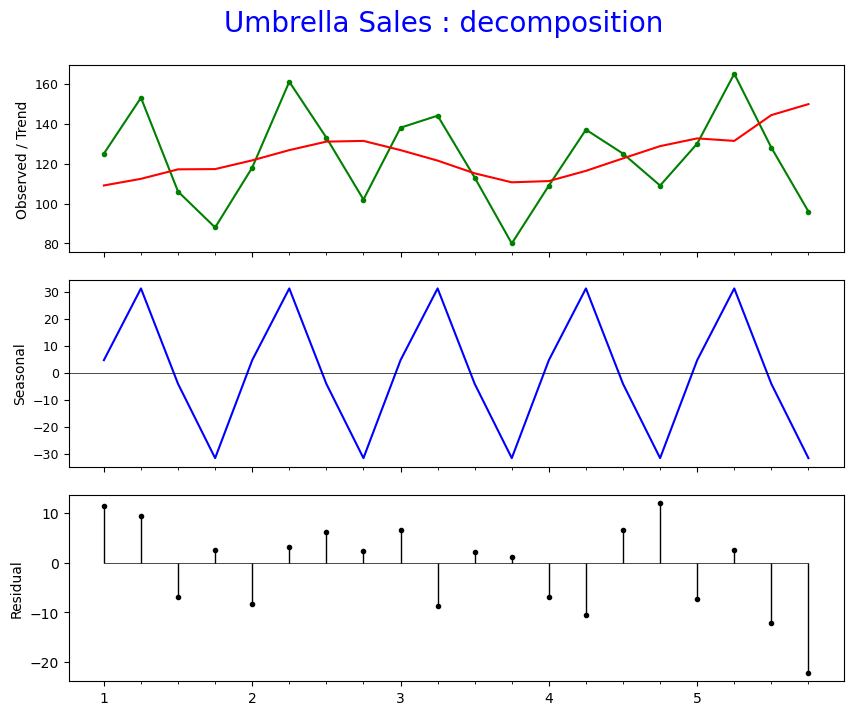

In [32]:
# 1. Load the data 
df4 = pd.read_excel("Umbrella.xlsx")
# Extracting the target series as a numpy array
y = df4.select_dtypes(include="number").iloc[:, 1].to_numpy()


# 2. Define Time Axis
# We create a time index that corresponds to the x-axis labels.
season_period = 4 
time_index = np.arange(len(y)) / season_period + 1

# 3. Perform Additive Decomposition
decomposition = seasonal_decompose(y, model='additive', period=season_period, extrapolate_trend='freq')

trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

# 4. Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Top Plot: Data and Trend ---
# Green line with dots for actual Data
ax1.plot(time_index, y, color='green', marker='.', linestyle='-', linewidth=1.5, label='Data')
# Red smooth line for Trend
ax1.plot(time_index, trend, color='red', linestyle='-', linewidth=1.5, label='Trend')
ax1.set_ylabel('Observed / Trend', fontsize=10)
ax1.tick_params(axis='y', labelsize=9)

# --- Middle Plot: Seasonal Component ---
# Blue oscillating line
ax2.plot(time_index, seasonal, color='blue', linestyle='-')
# Thin black zero line
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Seasonal', fontsize=10)
ax2.tick_params(axis='y', labelsize=9)

# --- Bottom Plot: Residuals ---
# Black "Lollipop" (stem) plot
# We style the stems (lines) and markers (dots) to be black
markerline, stemlines, baseline = ax3.stem(time_index, resid)
plt.setp(markerline, color='black', marker='.', markersize=6)
plt.setp(stemlines, color='black', linewidth=1)
plt.setp(baseline, color='black', linewidth=0.5) # The zero line
ax3.set_ylabel('Residual', fontsize=10)

# --- Formatting & Title ---
# Set X-axis ticks to match the image (1, 2, 3...)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25)) # Minor ticks for quarters

# Add the main title in Blue
fig.suptitle('Umbrella Sales : decomposition', fontsize=20, color='blue', y=0.95)

# Adjust layout to bring plots closer together
plt.subplots_adjust(hspace=0.15)

plt.show()

### Manual calculation

In [33]:
y = df4.select_dtypes(include="number").iloc[:, 1].to_numpy()
m = 4
n = len(y)

# 1) 4-term moving average
ma4 = np.full(n, np.nan)
for t in range(n - m + 1):
    ma4[t + m - 1] = np.mean(y[t:t+m])  # stored at end index just as a placeholder

# Centering: CMA at integer times
# MA4_t corresponds to between (t+1, t+2); so CMA aligns to t+2
cma = np.full(n, np.nan)
for t in range(n - m):
    ma_t   = np.mean(y[t:t+m])
    ma_t1  = np.mean(y[t+1:t+1+m])
    cma[t+2] = 0.5*(ma_t + ma_t1)

trend = cma

# 2) detrended
detrended = y - trend

# 3) seasonal indices by quarter
seasonal_idx = np.zeros(m)
counts = np.zeros(m)

for t in range(n):
    if np.isfinite(detrended[t]):
        q = t % m
        seasonal_idx[q] += detrended[t]
        counts[q] += 1

seasonal_idx = seasonal_idx / counts
seasonal_idx = seasonal_idx - seasonal_idx.mean()  # normalize to sum=0

seasonal = np.array([seasonal_idx[t % m] for t in range(n)])

# 4) residual
resid = y - trend - seasonal

result = pd.DataFrame({
    "t": np.arange(1, n+1),
    "Y": y,
    "Trend": trend,
    "Detrended": detrended,
    "Seasonal": seasonal,
    "Resid": resid
})

result


,t,Y,Trend,Detrended,Seasonal,Resid
0,1,125,NaN,NaN,0.945312,NaN
1,2,153,NaN,NaN,28.007812,NaN
2,3,106,117.125,-11.125,-1.960938,-9.164062
3,4,88,117.250,-29.250,-26.992188,-2.257812
4,5,118,121.625,-3.625,0.945312,-4.570312
5,6,161,126.750,34.250,28.007812,6.242188
6,7,133,131.000,2.000,-1.960938,3.960938
7,8,102,131.375,-29.375,-26.992188,-2.382812
8,9,138,126.750,11.250,0.945312,10.304688
9,10,144,121.500,22.500,28.007812,-5.507812


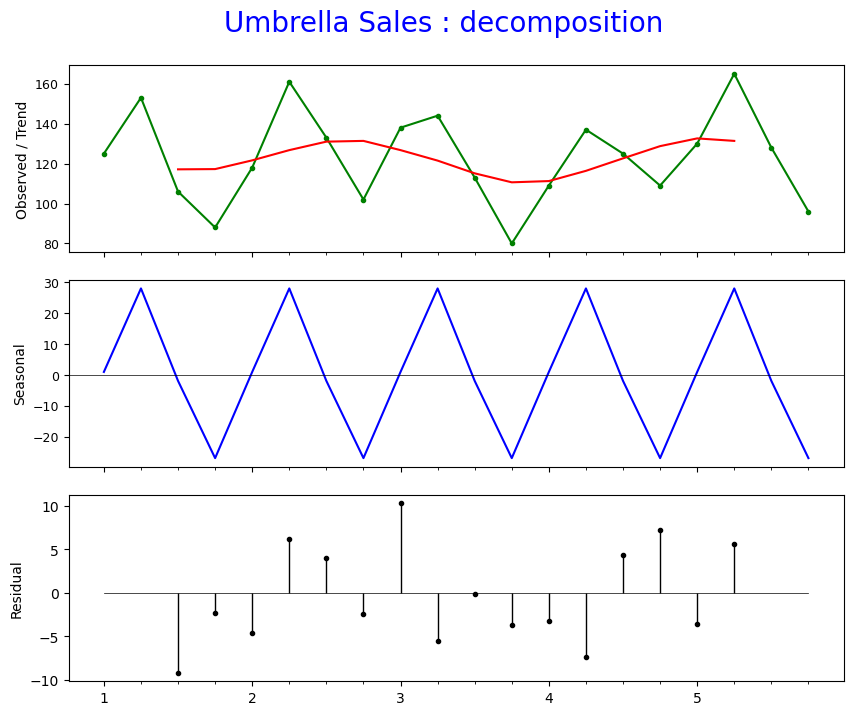

In [34]:
# 4. Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Top Plot: Data and Trend ---
# Green line with dots for actual Data
ax1.plot(time_index, y, color='green', marker='.', linestyle='-', linewidth=1.5, label='Data')
# Red smooth line for Trend
ax1.plot(time_index, trend, color='red', linestyle='-', linewidth=1.5, label='Trend')
ax1.set_ylabel('Observed / Trend', fontsize=10)
ax1.tick_params(axis='y', labelsize=9)

# --- Middle Plot: Seasonal Component ---
# Blue oscillating line
ax2.plot(time_index, seasonal, color='blue', linestyle='-')
# Thin black zero line
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Seasonal', fontsize=10)
ax2.tick_params(axis='y', labelsize=9)

# --- Bottom Plot: Residuals ---
# Black "Lollipop" (stem) plot
# We style the stems (lines) and markers (dots) to be black
markerline, stemlines, baseline = ax3.stem(time_index, resid)
plt.setp(markerline, color='black', marker='.', markersize=6)
plt.setp(stemlines, color='black', linewidth=1)
plt.setp(baseline, color='black', linewidth=0.5) # The zero line
ax3.set_ylabel('Residual', fontsize=10)

# --- Formatting & Title ---
# Set X-axis ticks to match the image (1, 2, 3...)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25)) # Minor ticks for quarters

# Add the main title in Blue
fig.suptitle('Umbrella Sales : decomposition', fontsize=20, color='blue', y=0.95)

# Adjust layout to bring plots closer together
plt.subplots_adjust(hspace=0.15)

plt.show()

In [35]:
df4

,Unnamed: 0,SeasIdx,Umbrella Sales
0,1(1),1,125
1,1(2),2,153
2,1(3),3,106
3,1(4),4,88
4,2(1),1,118
5,2(2),2,161
6,2(3),3,133
7,2(4),4,102
8,3(1),1,138
9,3(2),2,144


In [36]:
y

array([125, 153, 106,  88, 118, 161, 133, 102, 138, 144, 113,  80, 109,
       137, 125, 109, 130, 165, 128,  96], dtype=int64)

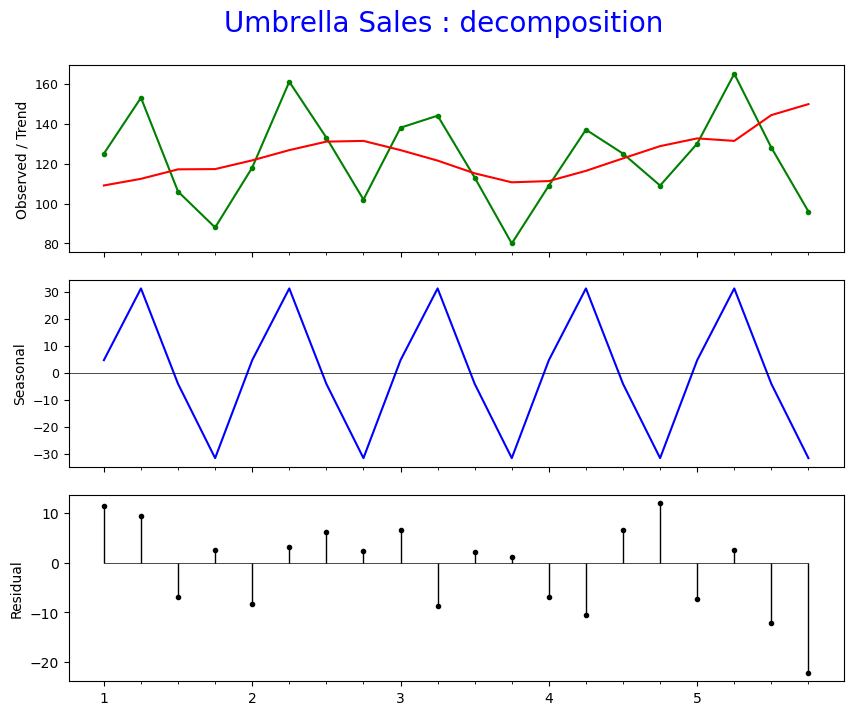

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load the data 
df4 = pd.read_excel("Umbrella.xlsx")
# Extracting the target series as a numpy array
y = df4.select_dtypes(include="number").iloc[:, 1].to_numpy()


# 2. Define Time Axis
# We create a time index that corresponds to the x-axis labels.
season_period = 4 
time_index = np.arange(len(y)) / season_period + 1

# 3. Perform Additive Decomposition
decomposition = seasonal_decompose(y, model='additive', period=season_period, extrapolate_trend='freq')

trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

# 4. Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Top Plot: Data and Trend ---
# Green line with dots for actual Data
ax1.plot(time_index, y, color='green', marker='.', linestyle='-', linewidth=1.5, label='Data')
# Red smooth line for Trend
ax1.plot(time_index, trend, color='red', linestyle='-', linewidth=1.5, label='Trend')
ax1.set_ylabel('Observed / Trend', fontsize=10)
ax1.tick_params(axis='y', labelsize=9)

# --- Middle Plot: Seasonal Component ---
# Blue oscillating line
ax2.plot(time_index, seasonal, color='blue', linestyle='-')
# Thin black zero line
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Seasonal', fontsize=10)
ax2.tick_params(axis='y', labelsize=9)

# --- Bottom Plot: Residuals ---
# Black "Lollipop" (stem) plot
# We style the stems (lines) and markers (dots) to be black
markerline, stemlines, baseline = ax3.stem(time_index, resid)
plt.setp(markerline, color='black', marker='.', markersize=6)
plt.setp(stemlines, color='black', linewidth=1)
plt.setp(baseline, color='black', linewidth=0.5) # The zero line
ax3.set_ylabel('Residual', fontsize=10)

# --- Formatting & Title ---
# Set X-axis ticks to match the image (1, 2, 3...)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25)) # Minor ticks for quarters

# Add the main title in Blue
fig.suptitle('Umbrella Sales : decomposition', fontsize=20, color='blue', y=0.95)

# Adjust layout to bring plots closer together
plt.subplots_adjust(hspace=0.15)

plt.show()

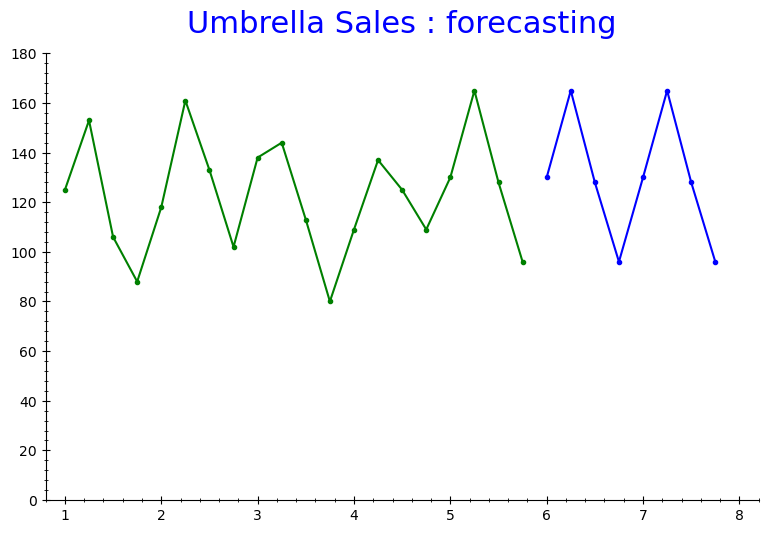

In [38]:
# -----------------------------
# Load data
# -----------------------------
df4 = pd.read_excel("Umbrella.xlsx")
y = df4.select_dtypes(include="number").iloc[:, 1].astype(float).to_numpy()

# -----------------------------
# Time axis (quarters -> 4 per year)
# -----------------------------
season_period = 4
t_obs = np.arange(len(y)) / season_period + 1   # e.g. 1.00, 1.25, ..., 5.75

# -----------------------------
# Seasonal Random Walk forecast (seasonal naive)
# -----------------------------
h = 8  # forecast horizon: 8 quarters = 2 years
last_season = y[-season_period:]                # last 4 observed values
y_fore = np.tile(last_season, int(np.ceil(h / season_period)))[:h]

t_fore = np.arange(len(y), len(y) + h) / season_period + 1  # starts at 6.00

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9.2, 5.8))

# observed (green)
ax.plot(t_obs, y, color="green", marker="o", markersize=3, linewidth=1.5)

# # split line at 6
# ax.axvline(6, color="gray", linewidth=1.5)

# forecast (blue)
ax.plot(t_fore, y_fore, color="blue", marker="o", markersize=3, linewidth=1.5)

ax.set_title("Umbrella Sales : forecasting", color="blue", fontsize=22, pad=15)

# axis styling to match the slide
ax.set_xlim(0.8, 8.2)
ax.set_ylim(0, 180)
ax.set_xticks(np.arange(1, 9, 1))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))  # quarters inside each year
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(which="major", length=6, direction="inout")
ax.tick_params(which="minor", length=3, direction="inout")

plt.show()
